# Retail Sales Analytics — Profit Margin Root-Cause Analysis

## Business Objective

Analyze retail sales performance across cities, categories, stores, and products to identify the factors associated with differences in profit margins and provide actionable business recommendations.

# 1. Dataset Overview & Data Quality

In [1]:
import piplite
await piplite.install('openpyxl')
await piplite.install('seaborn')
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter
from scipy.stats import mannwhitneyu

In [2]:
df=pd.read_excel("Retail_Sales_Analytics_Dataset.xlsx",
                parse_dates=['Date'])

In [3]:
df=df.sort_values(by=['Date']).reset_index(drop=True)

In [4]:
df

,Date,Store_ID,Store_City,Product_ID,Category,Customer_ID,Sales,Quantity,Profit,Discount,Payment_Mode,Returned
0,2024-01-01,S008,Mumbai,P035,Grocery,C0557,15046.96,4,967.11,20,Card,No
1,2024-01-01,S006,Pune,P117,Sports,C0893,20472.58,1,4273.87,20,UPI,No
2,2024-01-01,S007,Surat,P033,Electronics,C0637,12221.14,1,1802.34,20,UPI,No
3,2024-01-01,S010,Mumbai,P025,Grocery,C0838,3989.51,5,934.30,25,Card,No
4,2024-01-01,S004,Surat,P037,Furniture,C0982,8313.07,7,2480.65,10,Card,No
...,...,...,...,...,...,...,...,...,...,...,...,...
7995,2025-06-24,S008,Bengaluru,P019,Clothing,C0910,6834.37,1,1704.01,15,Cash,No
7996,2025-06-24,S003,Ahmedabad,P084,Grocery,C0424,10535.43,4,1430.28,0,UPI,No
7997,2025-06-24,S002,Delhi,P007,Electronics,C0249,7255.60,2,1662.69,15,Card,No
7998,2025-06-24,S007,Pune,P068,Furniture,C0866,10987.45,3,3135.80,10,Card,No


In [5]:
df.shape


(8000, 12)

In [6]:
df.columns

Index(['Date', 'Store_ID', 'Store_City', 'Product_ID', 'Category',
       'Customer_ID', 'Sales', 'Quantity', 'Profit', 'Discount',
       'Payment_Mode', 'Returned'],
      dtype='str')

In [7]:
df.info

<bound method DataFrame.info of            Date Store_ID Store_City Product_ID     Category Customer_ID  \
0    2024-01-01     S008     Mumbai       P035      Grocery       C0557   
1    2024-01-01     S006       Pune       P117       Sports       C0893   
2    2024-01-01     S007      Surat       P033  Electronics       C0637   
3    2024-01-01     S010     Mumbai       P025      Grocery       C0838   
4    2024-01-01     S004      Surat       P037    Furniture       C0982   
...         ...      ...        ...        ...          ...         ...   
7995 2025-06-24     S008  Bengaluru       P019     Clothing       C0910   
7996 2025-06-24     S003  Ahmedabad       P084      Grocery       C0424   
7997 2025-06-24     S002      Delhi       P007  Electronics       C0249   
7998 2025-06-24     S007       Pune       P068    Furniture       C0866   
7999 2025-06-24     S009  Bengaluru       P044      Grocery       C0703   

         Sales  Quantity   Profit  Discount Payment_Mode Returned  

In [8]:
df.describe(include='all')

,Date,Store_ID,Store_City,Product_ID,Category,Customer_ID,Sales,Quantity,Profit,Discount,Payment_Mode,Returned
count,8000,8000,8000,8000,8000,8000,8000.000000,8000.00000,8000.000000,8000.000000,8000,8000
unique,NaN,10,6,120,5,999,NaN,NaN,NaN,NaN,3,2
top,NaN,S005,Ahmedabad,P018,Clothing,C0564,NaN,NaN,NaN,NaN,Card,No
freq,NaN,831,1396,87,1659,18,NaN,NaN,NaN,NaN,2687,7200
mean,2024-09-24 14:29:34.800000,NaN,NaN,NaN,NaN,NaN,10080.332221,4.55325,1756.515239,12.457500,NaN,NaN
min,2024-01-01 00:00:00,NaN,NaN,NaN,NaN,NaN,174.540000,1.00000,12.150000,0.000000,NaN,NaN
25%,2024-05-15 00:00:00,NaN,NaN,NaN,NaN,NaN,5059.652500,3.00000,704.652500,5.000000,NaN,NaN
50%,2024-09-23 00:00:00,NaN,NaN,NaN,NaN,NaN,10001.595000,5.00000,1446.710000,10.000000,NaN,NaN
75%,2025-02-06 00:00:00,NaN,NaN,NaN,NaN,NaN,14781.437500,7.00000,2552.422500,20.000000,NaN,NaN
max,2025-06-24 00:00:00,NaN,NaN,NaN,NaN,NaN,23861.380000,8.00000,6872.210000,25.000000,NaN,NaN


In [9]:
df.isna().sum()

Date            0
Store_ID        0
Store_City      0
Product_ID      0
Category        0
Customer_ID     0
Sales           0
Quantity        0
Profit          0
Discount        0
Payment_Mode    0
Returned        0
dtype: int64

In [10]:
df.duplicated()

0       False
1       False
2       False
3       False
4       False
        ...  
7995    False
7996    False
7997    False
7998    False
7999    False
Length: 8000, dtype: bool

In [11]:
df.nunique()



Date             541
Store_ID          10
Store_City         6
Product_ID       120
Category           5
Customer_ID      999
Sales           7978
Quantity           8
Profit          7933
Discount           6
Payment_Mode       3
Returned           2
dtype: int64

In [12]:
df.duplicated().sum()

np.int64(0)

# 2. Exploratory Data Analysis

## 2.1 City × Category Performance

In [13]:
temp=df.groupby(by=['Category','Store_City'])[['Sales','Quantity','Profit']].agg({'Sales':['sum','mean'],
         'Quantity': 'sum',
         'Profit':'sum'})

In [14]:
temp

Sales               Quantity     Profit
                               sum          mean      sum        sum
Category    Store_City                                              
Clothing    Ahmedabad   2714441.59   9659.934484     1292  480574.36
            Bengaluru   2621660.86   9893.059849     1153  454217.33
            Delhi       2765638.32  10130.543297     1156  471031.59
            Mumbai      2778273.54   9887.094448     1272  476213.51
            Pune        2605753.26  10060.823398     1201  449722.14
            Surat       3112749.13  10375.830433     1400  527004.31
Electronics Ahmedabad   2753962.85  10314.467603     1226  472479.25
            Bengaluru   2647974.13   9992.355208     1152  484220.08
            Delhi       2804126.48  10123.200289     1343  503463.12
            Mumbai      2551791.23  10289.480766     1101  454786.47
            Pune        2657105.21  10141.622939     1169  451475.93
            Surat       2545483.26   9641.982045     1183  448391.91
Furniture   Ahmedabad   2940339.50   9546.556818     1433  486320.30
            Bengaluru   2585369.87  10218.853241     1163  434197.69
            Delhi       2517986.99   9797.614747     1102  444009.41
            Mumbai      2702645.62  10475.370620     1192  487916.36
            Pune        2736386.93  10858.678294     1212  460051.29
            Surat       3237007.10  10683.191749     1366  581472.37
Grocery     Ahmedabad   2628892.10   9883.053008     1209  457818.24
            Bengaluru   2523176.58   9704.525308     1172  420432.51
            Delhi       2928275.59  10028.341062     1363  515151.47
            Mumbai      2508886.63   9762.204786     1267  436275.61
            Pune        2539851.43  10324.599309     1120  434689.25
            Surat       2207969.50   9990.812217      959  367399.60
Sports      Ahmedabad   2768651.29  10104.566752     1259  501533.86
            Bengaluru   2672702.78  10359.313101     1163  473786.96
            Delhi       2650489.10   9816.626296     1212  479229.83
            Mumbai      2619484.82  10232.362578     1186  449884.67
            Pune        2462670.34  10218.549129     1113  454156.09
            Surat       2852911.74   9975.215874     1287  494216.40

In [15]:
temp.columns = ['_'.join(col) for col in temp.columns]


In [16]:
temp.columns

Index(['Sales_sum', 'Sales_mean', 'Quantity_sum', 'Profit_sum'], dtype='str')

In [17]:
temp

Sales_sum    Sales_mean  Quantity_sum  Profit_sum
Category    Store_City                                                    
Clothing    Ahmedabad   2714441.59   9659.934484          1292   480574.36
            Bengaluru   2621660.86   9893.059849          1153   454217.33
            Delhi       2765638.32  10130.543297          1156   471031.59
            Mumbai      2778273.54   9887.094448          1272   476213.51
            Pune        2605753.26  10060.823398          1201   449722.14
            Surat       3112749.13  10375.830433          1400   527004.31
Electronics Ahmedabad   2753962.85  10314.467603          1226   472479.25
            Bengaluru   2647974.13   9992.355208          1152   484220.08
            Delhi       2804126.48  10123.200289          1343   503463.12
            Mumbai      2551791.23  10289.480766          1101   454786.47
            Pune        2657105.21  10141.622939          1169   451475.93
            Surat       2545483.26   9641.982045          1183   448391.91
Furniture   Ahmedabad   2940339.50   9546.556818          1433   486320.30
            Bengaluru   2585369.87  10218.853241          1163   434197.69
            Delhi       2517986.99   9797.614747          1102   444009.41
            Mumbai      2702645.62  10475.370620          1192   487916.36
            Pune        2736386.93  10858.678294          1212   460051.29
            Surat       3237007.10  10683.191749          1366   581472.37
Grocery     Ahmedabad   2628892.10   9883.053008          1209   457818.24
            Bengaluru   2523176.58   9704.525308          1172   420432.51
            Delhi       2928275.59  10028.341062          1363   515151.47
            Mumbai      2508886.63   9762.204786          1267   436275.61
            Pune        2539851.43  10324.599309          1120   434689.25
            Surat       2207969.50   9990.812217           959   367399.60
Sports      Ahmedabad   2768651.29  10104.566752          1259   501533.86
            Bengaluru   2672702.78  10359.313101          1163   473786.96
            Delhi       2650489.10   9816.626296          1212   479229.83
            Mumbai      2619484.82  10232.362578          1186   449884.67
            Pune        2462670.34  10218.549129          1113   454156.09
            Surat       2852911.74   9975.215874          1287   494216.40

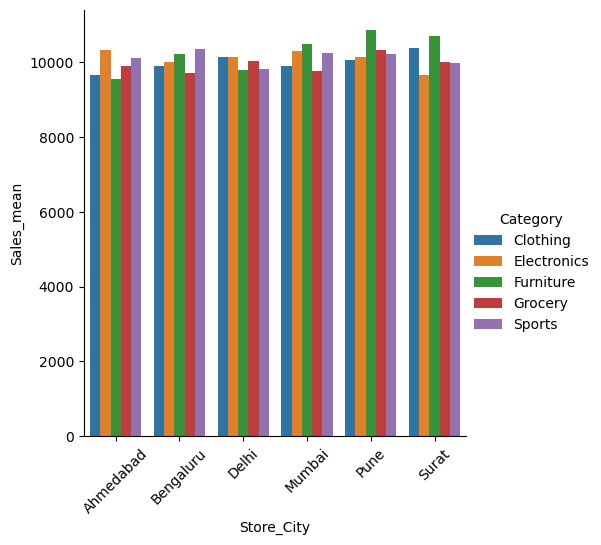

In [18]:
g=sns.catplot(
    data=temp,
    x='Store_City',
    y='Sales_mean',
    hue='Category',
    kind='bar')
g.set_xticklabels(rotation=45)

<Axes: xlabel='Store_City', ylabel='Sales_mean'>

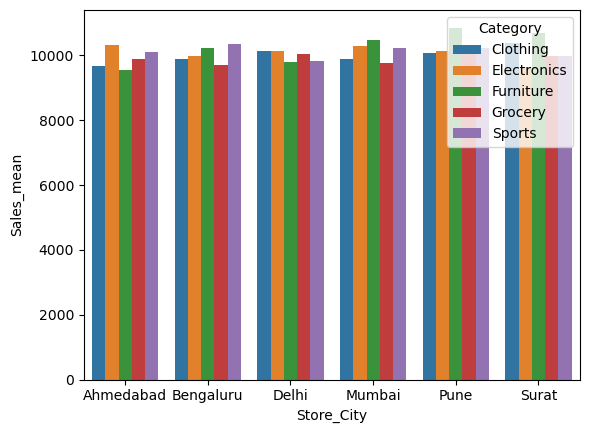

In [19]:
sns.barplot(data=temp,
            x='Store_City',
            y='Sales_mean',
            hue='Category')

In [20]:
temp.groupby(['Store_City', 'Category']).size()

Store_City  Category   
Ahmedabad   Clothing       1
            Electronics    1
            Furniture      1
            Grocery        1
            Sports         1
Bengaluru   Clothing       1
            Electronics    1
            Furniture      1
            Grocery        1
            Sports         1
Delhi       Clothing       1
            Electronics    1
            Furniture      1
            Grocery        1
            Sports         1
Mumbai      Clothing       1
            Electronics    1
            Furniture      1
            Grocery        1
            Sports         1
Pune        Clothing       1
            Electronics    1
            Furniture      1
            Grocery        1
            Sports         1
Surat       Clothing       1
            Electronics    1
            Furniture      1
            Grocery        1
            Sports         1
dtype: int64

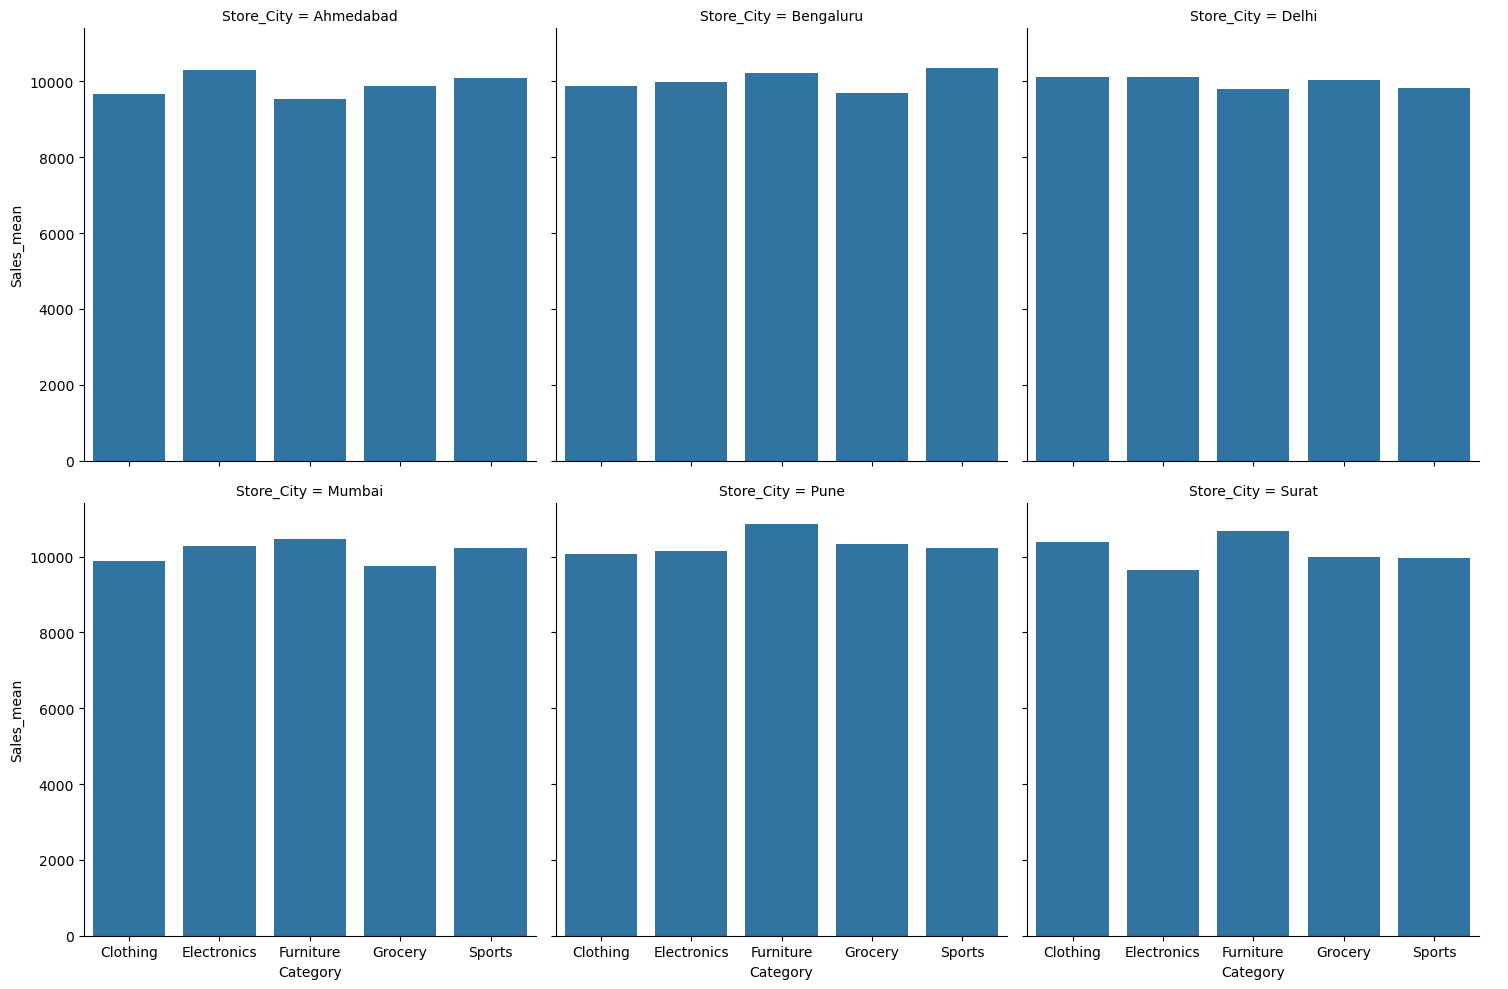

In [21]:
sns.catplot(data=temp,
            x='Category',
            y='Sales_mean',
            col='Store_City',
           kind='bar',
           col_wrap=3)

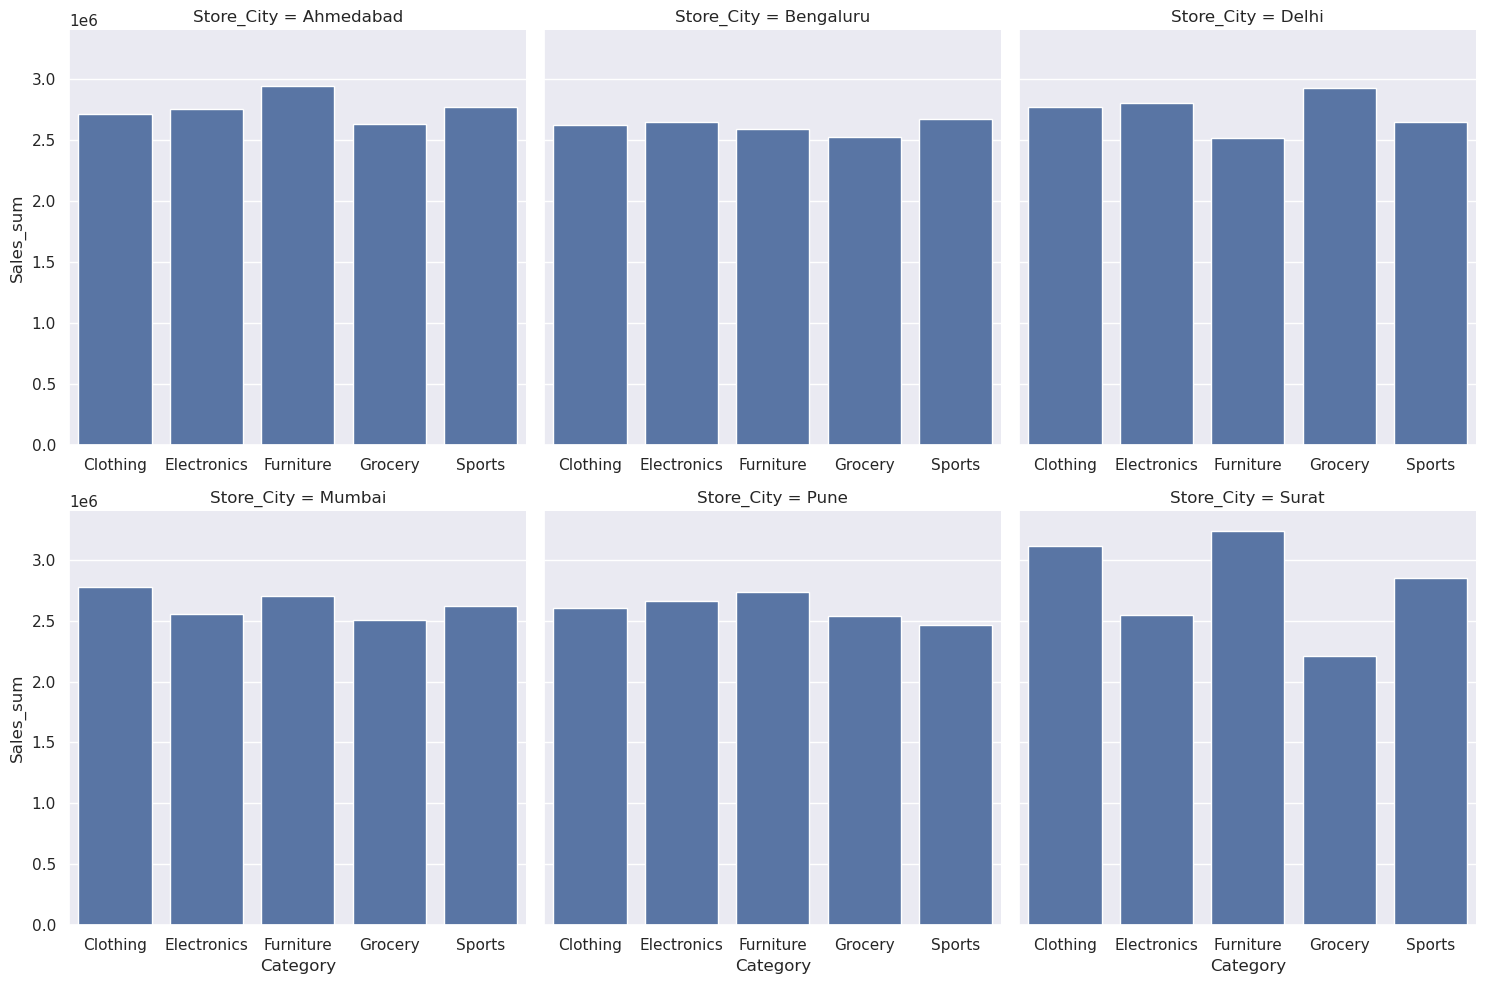

In [22]:
sns.set_theme(style="darkgrid", rc={"axes.grid.axis": "y"})

sns.catplot(data=temp,
            x='Category',
            y='Sales_sum',
            col='Store_City',
           kind='bar',
           col_wrap=3,
            sharex=False)

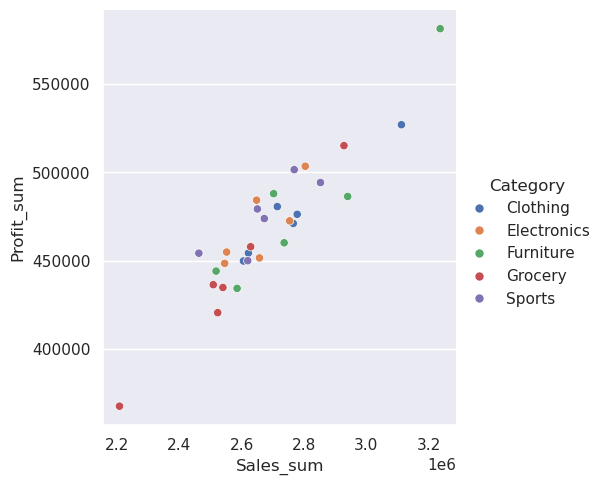

In [23]:
sns.set_theme(style="darkgrid", rc={"axes.grid.axis": "y"})

sns.relplot(data=temp,
            x='Sales_sum',
            y='Profit_sum',
            hue='Category',
           kind='scatter')

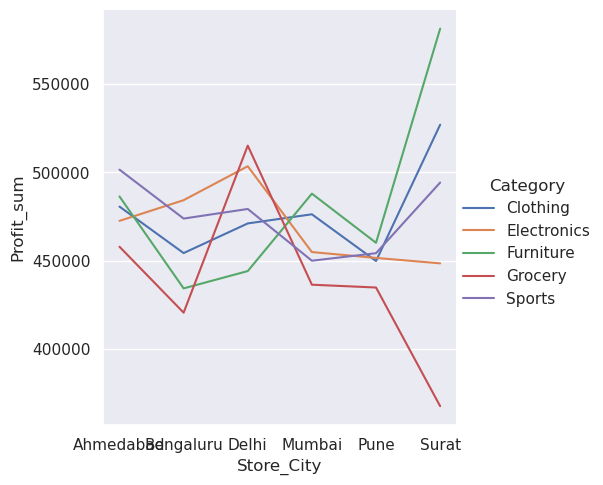

In [24]:
sns.relplot(data=temp,
            x='Store_City',
            y='Profit_sum',
            hue='Category',
           kind='line')

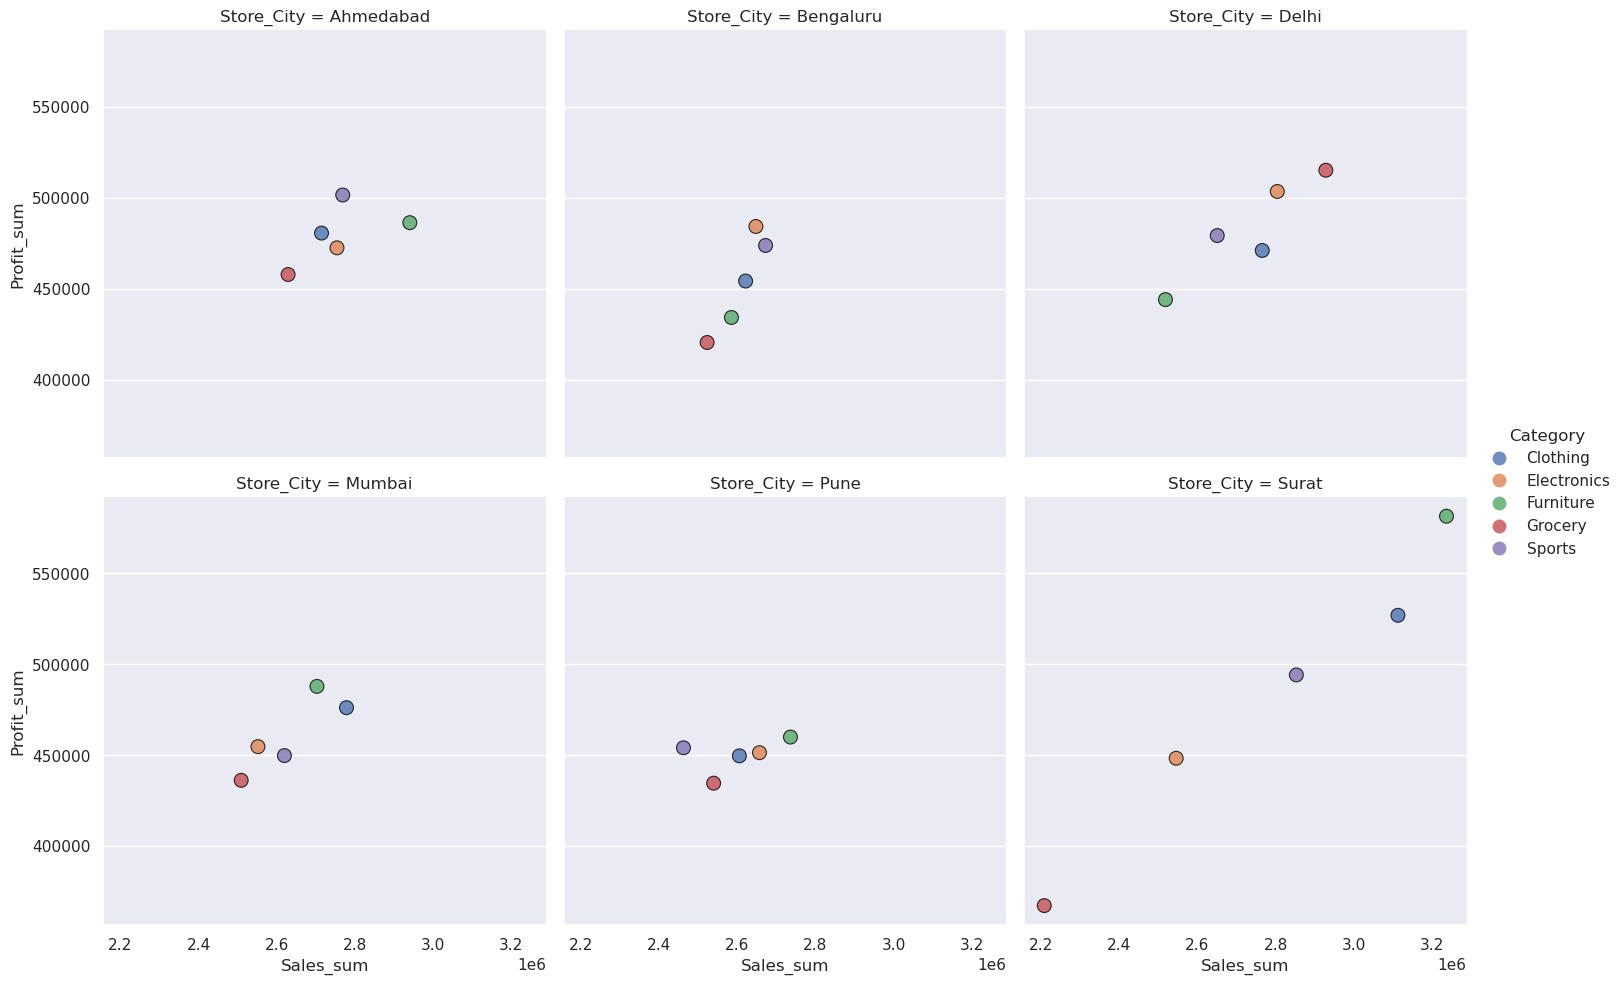

In [25]:
g = sns.relplot(
    data=temp,
    x='Sales_sum',
    y='Profit_sum',
    hue='Category',
    col='Store_City',
    kind='scatter',
    col_wrap=3,
    s=100,                
    edgecolor='black',
    alpha=0.8
)


# 3. Profit Margin Analysis

## 3.1 Profit Margin Across City × Category

In [26]:
temp['Profit_Margin']=temp['Profit_sum']/temp['Sales_sum']

In [27]:
temp 

Sales_sum    Sales_mean  Quantity_sum  Profit_sum  \
Category    Store_City                                                       
Clothing    Ahmedabad   2714441.59   9659.934484          1292   480574.36   
            Bengaluru   2621660.86   9893.059849          1153   454217.33   
            Delhi       2765638.32  10130.543297          1156   471031.59   
            Mumbai      2778273.54   9887.094448          1272   476213.51   
            Pune        2605753.26  10060.823398          1201   449722.14   
            Surat       3112749.13  10375.830433          1400   527004.31   
Electronics Ahmedabad   2753962.85  10314.467603          1226   472479.25   
            Bengaluru   2647974.13   9992.355208          1152   484220.08   
            Delhi       2804126.48  10123.200289          1343   503463.12   
            Mumbai      2551791.23  10289.480766          1101   454786.47   
            Pune        2657105.21  10141.622939          1169   451475.93   
            Surat       2545483.26   9641.982045          1183   448391.91   
Furniture   Ahmedabad   2940339.50   9546.556818          1433   486320.30   
            Bengaluru   2585369.87  10218.853241          1163   434197.69   
            Delhi       2517986.99   9797.614747          1102   444009.41   
            Mumbai      2702645.62  10475.370620          1192   487916.36   
            Pune        2736386.93  10858.678294          1212   460051.29   
            Surat       3237007.10  10683.191749          1366   581472.37   
Grocery     Ahmedabad   2628892.10   9883.053008          1209   457818.24   
            Bengaluru   2523176.58   9704.525308          1172   420432.51   
            Delhi       2928275.59  10028.341062          1363   515151.47   
            Mumbai      2508886.63   9762.204786          1267   436275.61   
            Pune        2539851.43  10324.599309          1120   434689.25   
            Surat       2207969.50   9990.812217           959   367399.60   
Sports      Ahmedabad   2768651.29  10104.566752          1259   501533.86   
            Bengaluru   2672702.78  10359.313101          1163   473786.96   
            Delhi       2650489.10   9816.626296          1212   479229.83   
            Mumbai      2619484.82  10232.362578          1186   449884.67   
            Pune        2462670.34  10218.549129          1113   454156.09   
            Surat       2852911.74   9975.215874          1287   494216.40   

                        Profit_Margin  
Category    Store_City                 
Clothing    Ahmedabad        0.177044  
            Bengaluru        0.173256  
            Delhi            0.170316  
            Mumbai           0.171406  
            Pune             0.172588  
            Surat            0.169305  
Electronics Ahmedabad        0.171563  
            Bengaluru        0.182864  
            Delhi            0.179544  
            Mumbai           0.178222  
            Pune             0.169913  
            Surat            0.176152  
Furniture   Ahmedabad        0.165396  
            Bengaluru        0.167944  
            Delhi            0.176335  
            Mumbai           0.180533  
            Pune             0.168124  
            Surat            0.179633  
Grocery     Ahmedabad        0.174149  
            Bengaluru        0.166628  
            Delhi            0.175923  
            Mumbai           0.173892  
            Pune             0.171148  
            Surat            0.166397  
Sports      Ahmedabad        0.181147  
            Bengaluru        0.177269  
            Delhi            0.180808  
            Mumbai           0.171745  
            Pune             0.184416  
            Surat            0.173232

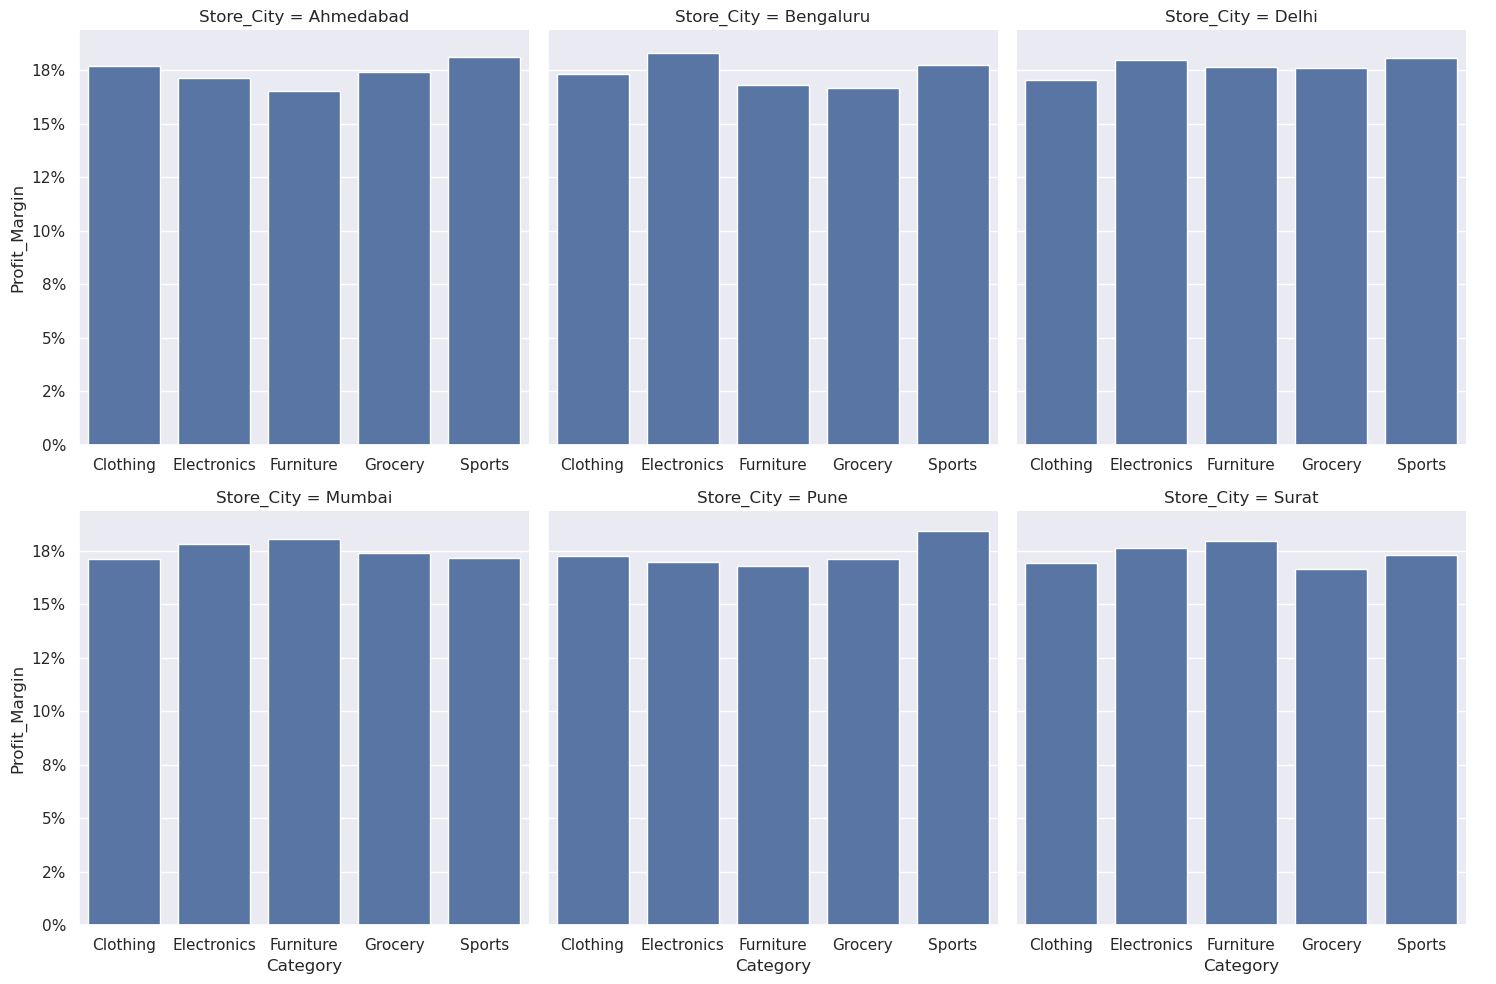

In [28]:
g=sns.catplot(
    data=temp,
    x='Category',
    y='Profit_Margin',
    col='Store_City',
    kind='bar',
    col_wrap=3,
    sharex=False)

for ax in g.axes.flat:
    ax.yaxis.set_major_formatter(PercentFormatter(xmax=1.0, decimals=0))

In [29]:
df[['Discount', 'Sales', 'Profit', 'Category', 'Store_City']].describe()

,Discount,Sales,Profit
count,8000.000000,8000.000000,8000.000000
mean,12.457500,10080.332221,1756.515239
std,8.588214,5856.060029,1312.553801
min,0.000000,174.540000,12.150000
25%,5.000000,5059.652500,704.652500
50%,10.000000,10001.595000,1446.710000
75%,20.000000,14781.437500,2552.422500
max,25.000000,23861.380000,6872.210000


<Axes: xlabel='Discount', ylabel='Profit'>

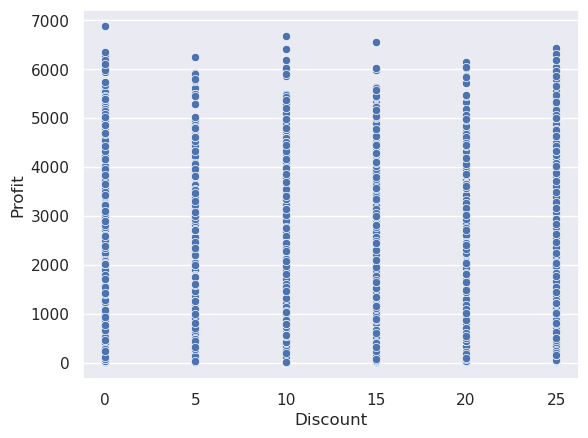

In [30]:
sns.scatterplot(data=df,
                x='Discount',
                y='Profit')

In [31]:
df['Profit_Margin'] = df['Profit'] / df['Sales']

<Axes: xlabel='Discount', ylabel='Profit_Margin'>

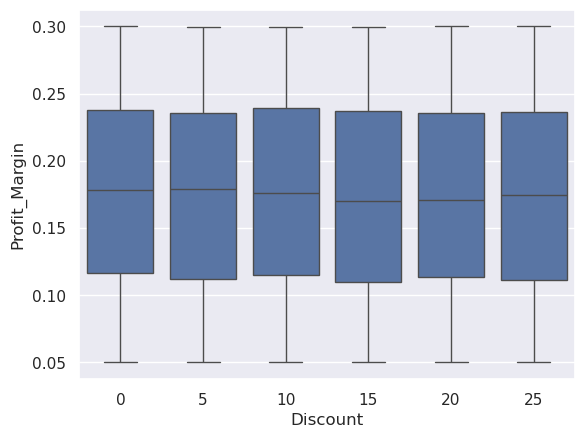

In [32]:
sns.boxplot(data=df,
                x='Discount',
                y='Profit_Margin')

In [33]:
df['Sales'].describe()

count     8000.000000
mean     10080.332221
std       5856.060029
min        174.540000
25%       5059.652500
50%      10001.595000
75%      14781.437500
max      23861.380000
Name: Sales, dtype: float64

In [34]:
(df['Sales'] == 0).sum()

np.int64(0)

In [35]:
df['Profit_Margin'].describe()

count    8000.000000
mean        0.174690
std         0.071845
min         0.050011
25%         0.112997
50%         0.175287
75%         0.237405
max         0.299989
Name: Profit_Margin, dtype: float64

In [36]:
df['Profit_Margin'].isna().sum(), np.isinf(df['Profit_Margin']).sum()

(np.int64(0), np.int64(0))

In [37]:
df['Discount'].value_counts().sort_index()

Discount
0     1360
5     1334
10    1338
15    1318
20    1282
25    1368
Name: count, dtype: int64

In [38]:
df['Profit_Margin'].describe(percentiles=[.01, .05, .25, .5, .75, .95, .99])

count    8000.000000
mean        0.174690
std         0.071845
min         0.050011
1%          0.052384
5%          0.062543
25%         0.112997
50%         0.175287
75%         0.237405
95%         0.286598
99%         0.297548
max         0.299989
Name: Profit_Margin, dtype: float64

In [39]:
df.nlargest(10, 'Profit_Margin')[['Sales', 'Profit', 'Discount', 'Profit_Margin']]

,Sales,Profit,Discount,Profit_Margin
5820,12125.53,3637.53,20,0.299989
7714,14808.36,4442.12,20,0.299974
989,8350.69,2504.83,0,0.299955
4298,13017.15,3904.53,25,0.299953
5466,18706.59,5610.97,15,0.299946
1533,15716.31,4713.83,15,0.299932
4734,17326.40,5196.71,20,0.299930
5889,1230.90,369.12,10,0.299878
7266,17777.09,5330.53,25,0.299854
3000,2743.75,822.68,10,0.299838


In [40]:
df.nsmallest(10, 'Profit_Margin')[['Sales', 'Profit', 'Discount', 'Profit_Margin']]

,Sales,Profit,Discount,Profit_Margin
5028,10264.44,513.33,10,0.050011
3238,11627.05,581.64,20,0.050025
7410,19754.11,989.11,20,0.050071
6207,7238.07,362.64,25,0.050102
4835,4953.35,248.33,25,0.050134
6680,14282.66,716.59,10,0.050172
303,7047.03,353.93,20,0.050224
6545,7963.00,400.54,20,0.050300
507,9685.02,487.24,20,0.050309
6477,17000.03,855.51,0,0.050324


<Axes: xlabel='Discount', ylabel='Profit_Margin'>

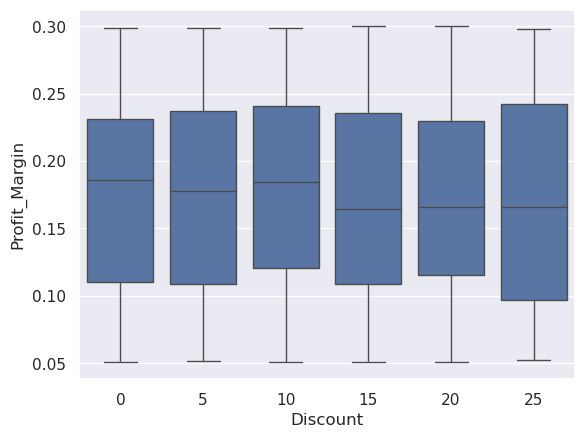

In [41]:
sns.boxplot(
    data=df.sample(1000, random_state=42),
    x='Discount',
    y='Profit_Margin'
)

In [42]:
temp1=df[(df['Store_City']=='Surat') & (df['Category']=='Grocery')]

In [43]:
temp1

,Date,Store_ID,Store_City,Product_ID,Category,Customer_ID,Sales,Quantity,Profit,Discount,Payment_Mode,Returned,Profit_Margin
11,2024-01-01,S008,Surat,P012,Grocery,C0441,4932.18,7,521.42,10,UPI,No,0.105718
86,2024-01-05,S010,Surat,P068,Grocery,C0213,13751.74,4,4065.30,5,Cash,No,0.295621
96,2024-01-06,S001,Surat,P100,Grocery,C0981,14341.26,6,3288.26,10,UPI,No,0.229287
107,2024-01-07,S002,Surat,P005,Grocery,C0431,6618.46,4,341.40,0,UPI,No,0.051583
160,2024-01-10,S006,Surat,P027,Grocery,C0193,7488.59,8,1623.63,10,UPI,No,0.216814
...,...,...,...,...,...,...,...,...,...,...,...,...,...
7802,2025-06-10,S007,Surat,P117,Grocery,C0277,4705.06,7,1314.74,20,Cash,Yes,0.279431
7815,2025-06-11,S008,Surat,P062,Grocery,C0380,3573.18,2,778.73,0,Card,No,0.217938
7840,2025-06-12,S003,Surat,P066,Grocery,C0567,16819.83,1,2948.24,25,Card,No,0.175284
7847,2025-06-13,S009,Surat,P037,Grocery,C0995,8516.41,3,684.70,25,Card,No,0.080398


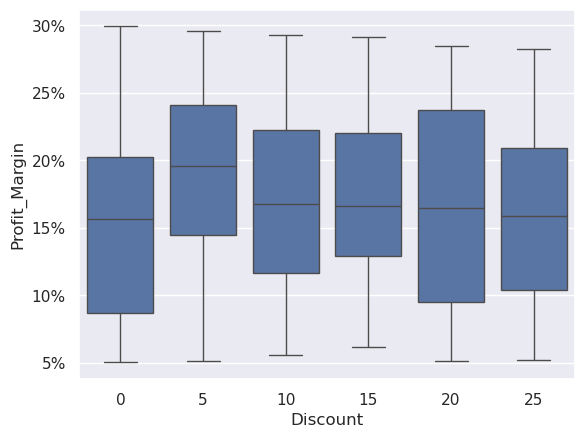

In [44]:
ax=sns.boxplot(data=temp1,
            x='Discount',
            y='Profit_Margin')


ax.yaxis.set_major_formatter(PercentFormatter(xmax=1.0, decimals=0))

In [45]:
temp2=df[df['Category']=='Grocery']
temp2

,Date,Store_ID,Store_City,Product_ID,Category,Customer_ID,Sales,Quantity,Profit,Discount,Payment_Mode,Returned,Profit_Margin
0,2024-01-01,S008,Mumbai,P035,Grocery,C0557,15046.96,4,967.11,20,Card,No,0.064273
3,2024-01-01,S010,Mumbai,P025,Grocery,C0838,3989.51,5,934.30,25,Card,No,0.234189
8,2024-01-01,S001,Delhi,P119,Grocery,C0020,1899.48,3,424.42,0,Cash,No,0.223440
11,2024-01-01,S008,Surat,P012,Grocery,C0441,4932.18,7,521.42,10,UPI,No,0.105718
17,2024-01-01,S008,Delhi,P028,Grocery,C0865,9742.44,3,880.41,15,Card,No,0.090369
...,...,...,...,...,...,...,...,...,...,...,...,...,...
7984,2025-06-23,S007,Delhi,P020,Grocery,C0448,7837.20,4,559.65,20,Card,No,0.071409
7988,2025-06-24,S007,Ahmedabad,P058,Grocery,C0443,12350.71,5,3017.33,20,Card,No,0.244304
7989,2025-06-24,S005,Bengaluru,P010,Grocery,C0087,15173.85,8,1988.42,10,UPI,No,0.131043
7996,2025-06-24,S003,Ahmedabad,P084,Grocery,C0424,10535.43,4,1430.28,0,UPI,No,0.135759


<Axes: xlabel='Store_City', ylabel='Profit_Margin'>

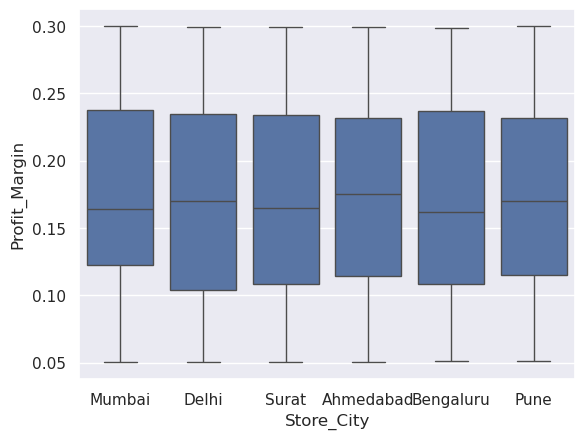

In [46]:
sns.boxplot(data=temp2,
            x='Store_City',
            y='Profit_Margin')

<Axes: xlabel='Store_City', ylabel='Profit_Margin'>

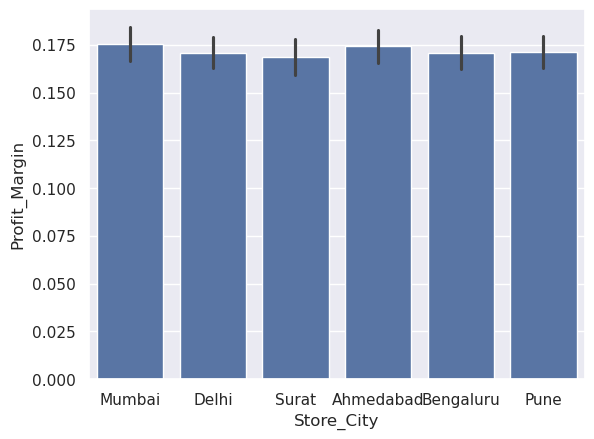

In [47]:
sns.barplot(data=temp2,
            x='Store_City',
            y='Profit_Margin') 

In [48]:
# Drop the unwanted columns safely
temp3=temp.reset_index() 
temp3




,Category,Store_City,Sales_sum,Sales_mean,Quantity_sum,Profit_sum,Profit_Margin
0,Clothing,Ahmedabad,2714441.59,9659.934484,1292,480574.36,0.177044
1,Clothing,Bengaluru,2621660.86,9893.059849,1153,454217.33,0.173256
2,Clothing,Delhi,2765638.32,10130.543297,1156,471031.59,0.170316
3,Clothing,Mumbai,2778273.54,9887.094448,1272,476213.51,0.171406
4,Clothing,Pune,2605753.26,10060.823398,1201,449722.14,0.172588
5,Clothing,Surat,3112749.13,10375.830433,1400,527004.31,0.169305
6,Electronics,Ahmedabad,2753962.85,10314.467603,1226,472479.25,0.171563
7,Electronics,Bengaluru,2647974.13,9992.355208,1152,484220.08,0.182864
8,Electronics,Delhi,2804126.48,10123.200289,1343,503463.12,0.179544
9,Electronics,Mumbai,2551791.23,10289.480766,1101,454786.47,0.178222


In [49]:
temp3=temp3[temp3['Category'] == 'Grocery']

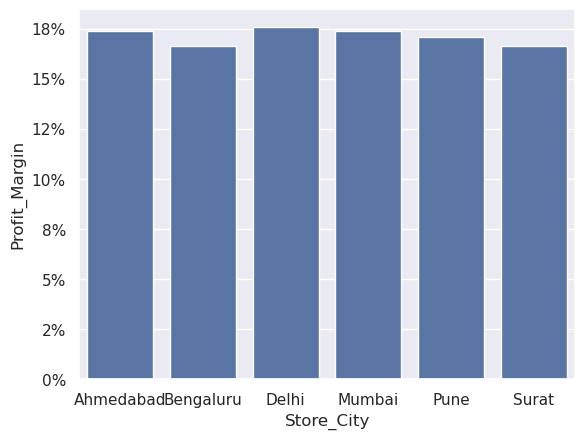

In [50]:
ax=sns.barplot(data=temp3,
            x='Store_City',
            y='Profit_Margin')

ax.yaxis.set_major_formatter(PercentFormatter(xmax=1.0, decimals=0))

# 4. Bengaluru Grocery Margin Investigation

The initial analysis identified Bengaluru Grocery as a relatively lower-margin city-category combination. This section investigates potential factors that could explain the margin difference.

In [51]:
beng_temp=df[(df['Store_City']=='Bengaluru') & (df['Category']=='Grocery')]

In [52]:
beng_temp1=df[df['Store_City']=='Bengaluru']

<Axes: xlabel='Category', ylabel='Profit_Margin'>

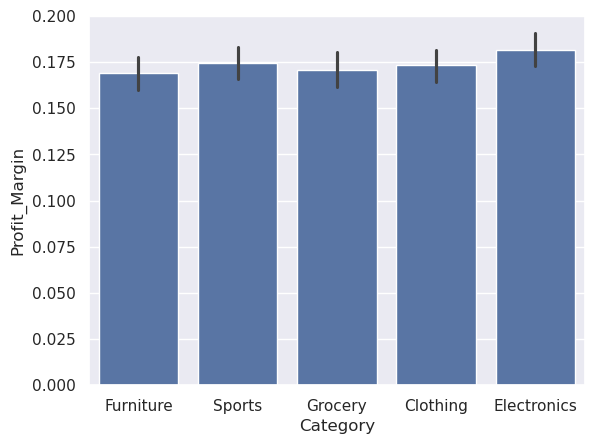

In [53]:
sns.barplot(data=beng_temp1,
            x='Category',
            y='Profit_Margin')

## 4.1 Discount Analysis

<Axes: xlabel='Discount', ylabel='Profit_Margin'>

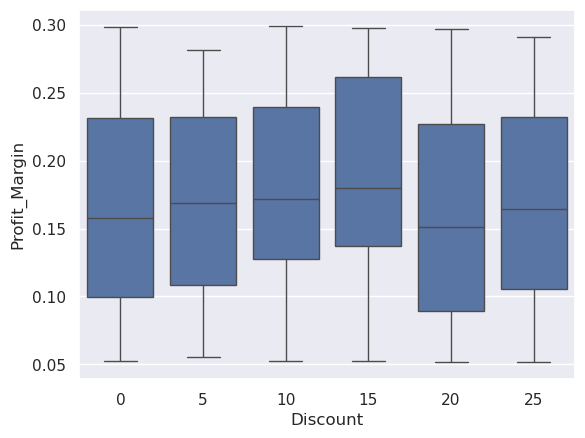

In [54]:
sns.boxplot(data=beng_temp,
            x='Discount',
            y='Profit_Margin')

In [55]:
beng_temp

,Date,Store_ID,Store_City,Product_ID,Category,Customer_ID,Sales,Quantity,Profit,Discount,Payment_Mode,Returned,Profit_Margin
48,2024-01-03,S008,Bengaluru,P031,Grocery,C0424,5341.44,8,1070.97,10,Card,No,0.200502
53,2024-01-04,S008,Bengaluru,P076,Grocery,C0377,6001.23,5,1581.76,5,Cash,No,0.263573
98,2024-01-06,S002,Bengaluru,P083,Grocery,C0233,14511.47,7,4270.11,10,UPI,No,0.294258
101,2024-01-07,S002,Bengaluru,P059,Grocery,C0107,9211.56,3,1112.16,0,Cash,No,0.120735
151,2024-01-10,S010,Bengaluru,P073,Grocery,C0886,18168.95,5,5196.74,0,UPI,No,0.286023
...,...,...,...,...,...,...,...,...,...,...,...,...,...
7905,2025-06-17,S005,Bengaluru,P054,Grocery,C0054,4141.12,6,1098.59,20,Cash,No,0.265288
7924,2025-06-18,S008,Bengaluru,P053,Grocery,C0519,11991.42,3,1525.65,15,Card,No,0.127228
7962,2025-06-21,S004,Bengaluru,P055,Grocery,C0228,10513.26,4,1272.77,5,UPI,No,0.121063
7989,2025-06-24,S005,Bengaluru,P010,Grocery,C0087,15173.85,8,1988.42,10,UPI,No,0.131043


In [56]:
tempdf=beng_temp.groupby(by='Discount')['Profit_Margin'].median()

In [57]:
tempdf

Discount
0     0.158083
5     0.168746
10    0.171656
15    0.180212
20    0.151345
25    0.164593
Name: Profit_Margin, dtype: float64

In [58]:
bengdf=beng_temp[beng_temp['Discount']==20]

In [59]:
bengdf

,Date,Store_ID,Store_City,Product_ID,Category,Customer_ID,Sales,Quantity,Profit,Discount,Payment_Mode,Returned,Profit_Margin
309,2024-01-22,S007,Bengaluru,P107,Grocery,C0246,1746.16,6,179.08,20,Card,No,0.102556
623,2024-02-13,S009,Bengaluru,P052,Grocery,C0026,642.65,2,73.93,20,UPI,No,0.115039
882,2024-03-02,S010,Bengaluru,P047,Grocery,C0304,22281.24,3,4217.90,20,Card,No,0.189303
1018,2024-03-11,S001,Bengaluru,P057,Grocery,C0876,8045.13,7,731.33,20,Cash,No,0.090903
1146,2024-03-19,S007,Bengaluru,P096,Grocery,C0379,7216.60,7,1160.63,20,Cash,No,0.160828
1189,2024-03-23,S006,Bengaluru,P094,Grocery,C0431,9593.25,4,1636.76,20,UPI,No,0.170616
1698,2024-04-26,S006,Bengaluru,P007,Grocery,C0524,8065.13,5,1249.97,20,Cash,No,0.154984
1849,2024-05-06,S002,Bengaluru,P054,Grocery,C0523,16206.41,5,2347.96,20,Cash,No,0.144878
1888,2024-05-09,S010,Bengaluru,P086,Grocery,C0429,2631.26,8,780.64,20,UPI,No,0.296679
1895,2024-05-09,S005,Bengaluru,P017,Grocery,C0095,11000.24,3,905.15,20,UPI,No,0.082285


In [60]:
grouped=bengdf.groupby('Product_ID')[['Sales','Profit']].sum()
grouped.columns=['Sales_sum','Profit_sum']

In [61]:
grouped

,Sales_sum,Profit_sum
Product_ID,,
P007,8065.13,1249.97
P009,9466.69,1432.94
P010,28931.89,3461.71
P011,2000.48,550.29
P017,11000.24,905.15
P023,15792.94,3855.06
P024,10522.47,573.10
P029,14564.60,2931.96
P033,362.09,65.52


In [62]:
grouped['Profit_margin']=grouped['Profit_sum']/grouped['Sales_sum']*100

In [63]:
grouped

,Sales_sum,Profit_sum,Profit_margin
Product_ID,,,
P007,8065.13,1249.97,15.498448
P009,9466.69,1432.94,15.136653
P010,28931.89,3461.71,11.965032
P011,2000.48,550.29,27.507898
P017,11000.24,905.15,8.228457
P023,15792.94,3855.06,24.410021
P024,10522.47,573.10,5.446440
P029,14564.60,2931.96,20.130728
P033,362.09,65.52,18.094949


<function matplotlib.pyplot.show(close=None, block=None)>

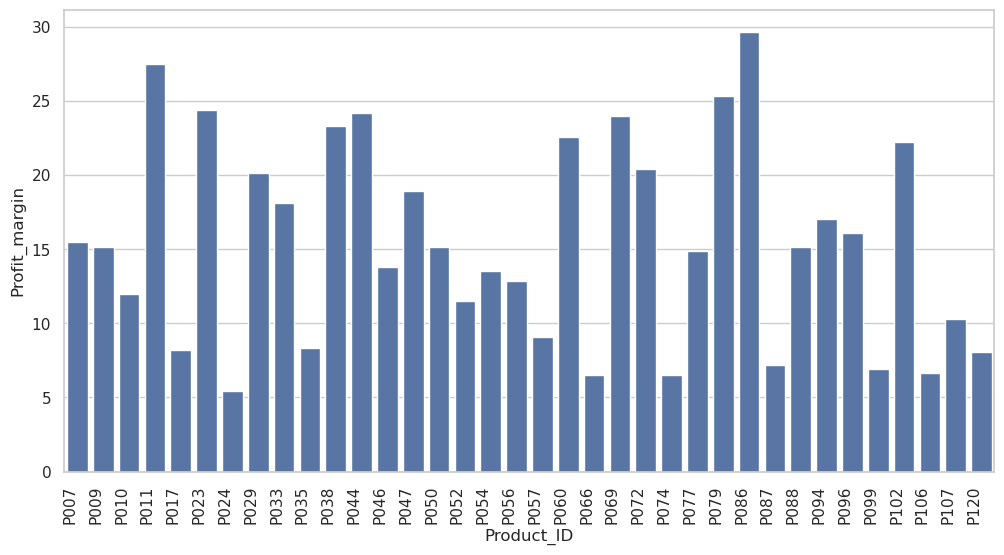

In [64]:

sns.set_theme(style="whitegrid")
plt.figure(figsize=(12, 6))
sns.barplot(data=grouped,
            x='Product_ID',
            y='Profit_margin')
plt.xticks(rotation=90, ha='right')
plt.show

<Axes: xlabel='Sales_sum', ylabel='Profit_margin'>

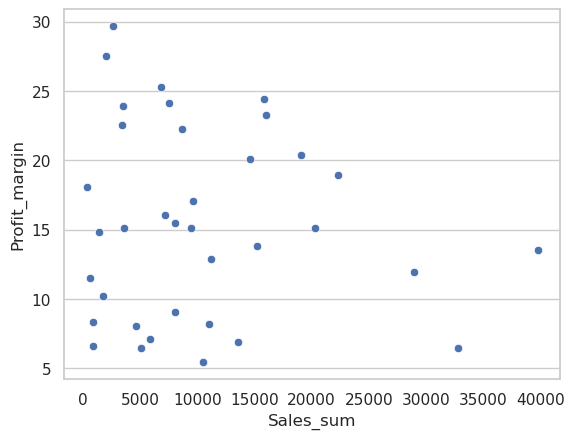

In [65]:
sns.scatterplot(data=grouped,
                x='Sales_sum',
                y='Profit_margin')

In [66]:
three_product=beng_temp[beng_temp['Product_ID'].isin(['P010','P054','P074'])]

In [67]:
three_product

,Date,Store_ID,Store_City,Product_ID,Category,Customer_ID,Sales,Quantity,Profit,Discount,Payment_Mode,Returned,Profit_Margin
472,2024-02-02,S001,Bengaluru,P010,Grocery,C0152,7129.75,8,1791.06,0,UPI,No,0.251209
1849,2024-05-06,S002,Bengaluru,P054,Grocery,C0523,16206.41,5,2347.96,20,Cash,No,0.144878
2196,2024-05-27,S003,Bengaluru,P010,Grocery,C0776,11035.67,5,1157.70,20,Cash,No,0.104905
2626,2024-06-23,S001,Bengaluru,P074,Grocery,C0822,13034.38,7,1066.80,20,UPI,No,0.081845
4306,2024-10-13,S004,Bengaluru,P054,Grocery,C0799,14031.67,1,1651.89,10,UPI,No,0.117726
4768,2024-11-13,S007,Bengaluru,P074,Grocery,C0630,19737.04,4,1064.34,20,Card,No,0.053926
5289,2024-12-21,S004,Bengaluru,P010,Grocery,C0733,17896.22,5,2304.01,20,Cash,No,0.128743
5321,2024-12-23,S005,Bengaluru,P074,Grocery,C0605,2966.84,1,682.96,25,Cash,No,0.230198
6292,2025-02-24,S008,Bengaluru,P054,Grocery,C0368,1523.17,6,78.31,20,UPI,No,0.051413
7404,2025-05-12,S001,Bengaluru,P054,Grocery,C0468,17899.76,3,1845.90,20,UPI,No,0.103124


In [68]:
avg=three_product.groupby('Product_ID')['Discount'].mean()
avg=avg.reset_index()

In [69]:
three_product.groupby(by=['Product_ID','Discount']).size()

Product_ID  Discount
P010        0           2
            10          1
            20          2
P054        10          1
            20          4
P074        20          2
            25          1
dtype: int64

In [70]:
three_product.groupby(by=['Product_ID','Discount']).size()

Product_ID  Discount
P010        0           2
            10          1
            20          2
P054        10          1
            20          4
P074        20          2
            25          1
dtype: int64

In [71]:
P074=three_product.groupby(by=['Product_ID','Discount'])['Profit_Margin'].median()*100                            

In [72]:
P074=P074.reset_index()

In [73]:
P074[P074['Product_ID']=='P074']

,Product_ID,Discount,Profit_Margin
5,P074,20,6.788555
6,P074,25,23.019779


In [74]:
beng_temp

,Date,Store_ID,Store_City,Product_ID,Category,Customer_ID,Sales,Quantity,Profit,Discount,Payment_Mode,Returned,Profit_Margin
48,2024-01-03,S008,Bengaluru,P031,Grocery,C0424,5341.44,8,1070.97,10,Card,No,0.200502
53,2024-01-04,S008,Bengaluru,P076,Grocery,C0377,6001.23,5,1581.76,5,Cash,No,0.263573
98,2024-01-06,S002,Bengaluru,P083,Grocery,C0233,14511.47,7,4270.11,10,UPI,No,0.294258
101,2024-01-07,S002,Bengaluru,P059,Grocery,C0107,9211.56,3,1112.16,0,Cash,No,0.120735
151,2024-01-10,S010,Bengaluru,P073,Grocery,C0886,18168.95,5,5196.74,0,UPI,No,0.286023
...,...,...,...,...,...,...,...,...,...,...,...,...,...
7905,2025-06-17,S005,Bengaluru,P054,Grocery,C0054,4141.12,6,1098.59,20,Cash,No,0.265288
7924,2025-06-18,S008,Bengaluru,P053,Grocery,C0519,11991.42,3,1525.65,15,Card,No,0.127228
7962,2025-06-21,S004,Bengaluru,P055,Grocery,C0228,10513.26,4,1272.77,5,UPI,No,0.121063
7989,2025-06-24,S005,Bengaluru,P010,Grocery,C0087,15173.85,8,1988.42,10,UPI,No,0.131043


In [75]:
for_SC=beng_temp.groupby('Product_ID')[['Sales','Profit']].sum()
for_SC.columns=['Sales_sum','Profit_sum']

In [76]:
for_SC

,Sales_sum,Profit_sum
Product_ID,,
P001,14866.52,1733.22
P002,17574.75,1908.95
P003,14694.43,2695.34
P004,34300.94,8779.20
P006,18175.02,3275.35
...,...,...
P114,22460.46,5551.99
P115,1851.47,551.66
P117,32894.96,5822.23


In [77]:
for_SC['Profit_Margin']=for_SC['Profit_sum']/for_SC['Sales_sum']

In [78]:
for_SC['Sales_contribution']=(for_SC['Sales_sum']/for_SC['Sales_sum'].sum())*100

In [79]:
for_SC.head(7)

,Sales_sum,Profit_sum,Profit_Margin,Sales_contribution
Product_ID,,,,
P001,14866.52,1733.22,0.116585,0.589199
P002,17574.75,1908.95,0.108619,0.696533
P003,14694.43,2695.34,0.183426,0.582378
P004,34300.94,8779.20,0.255946,1.359435
P006,18175.02,3275.35,0.180212,0.720323
P007,8065.13,1249.97,0.154984,0.319642
P009,29217.29,5209.32,0.178296,1.157957


In [80]:
for_SC.sort_values(by='Profit_Margin')

,Sales_sum,Profit_sum,Profit_Margin,Sales_contribution
Product_ID,,,,
P036,16089.18,843.69,0.052438,0.637656
P032,4593.28,244.62,0.053256,0.182044
P049,751.65,42.40,0.056409,0.029790
P066,5107.89,331.37,0.064874,0.202439
P099,13546.67,933.81,0.068933,0.536889
...,...,...,...,...
P030,2504.38,691.76,0.276220,0.099255
P106,12012.60,3332.60,0.277425,0.476090
P058,20667.15,6007.84,0.290695,0.819092


<Axes: xlabel='Sales_contribution', ylabel='Profit_Margin'>

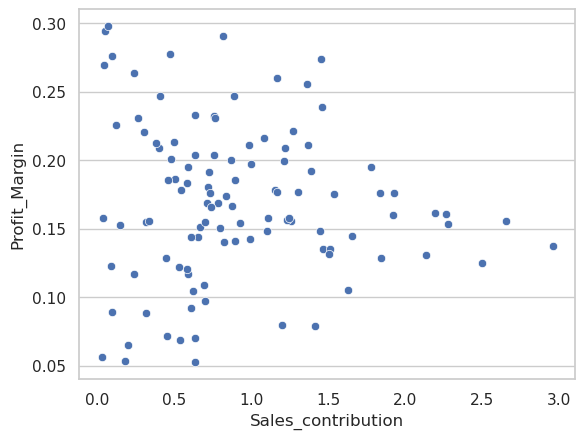

In [81]:
sns.scatterplot(data=for_SC,
                x='Sales_contribution',
                y='Profit_Margin')

In [82]:
temp2

,Date,Store_ID,Store_City,Product_ID,Category,Customer_ID,Sales,Quantity,Profit,Discount,Payment_Mode,Returned,Profit_Margin
0,2024-01-01,S008,Mumbai,P035,Grocery,C0557,15046.96,4,967.11,20,Card,No,0.064273
3,2024-01-01,S010,Mumbai,P025,Grocery,C0838,3989.51,5,934.30,25,Card,No,0.234189
8,2024-01-01,S001,Delhi,P119,Grocery,C0020,1899.48,3,424.42,0,Cash,No,0.223440
11,2024-01-01,S008,Surat,P012,Grocery,C0441,4932.18,7,521.42,10,UPI,No,0.105718
17,2024-01-01,S008,Delhi,P028,Grocery,C0865,9742.44,3,880.41,15,Card,No,0.090369
...,...,...,...,...,...,...,...,...,...,...,...,...,...
7984,2025-06-23,S007,Delhi,P020,Grocery,C0448,7837.20,4,559.65,20,Card,No,0.071409
7988,2025-06-24,S007,Ahmedabad,P058,Grocery,C0443,12350.71,5,3017.33,20,Card,No,0.244304
7989,2025-06-24,S005,Bengaluru,P010,Grocery,C0087,15173.85,8,1988.42,10,UPI,No,0.131043
7996,2025-06-24,S003,Ahmedabad,P084,Grocery,C0424,10535.43,4,1430.28,0,UPI,No,0.135759


In [83]:
temp2.groupby('Store_City')['Discount'].median()

Store_City
Ahmedabad    10.0
Bengaluru    10.0
Delhi        10.0
Mumbai       15.0
Pune         10.0
Surat        10.0
Name: Discount, dtype: float64

## 4.2 Returns Analysis

In [84]:
returned=temp2.groupby(['Store_City', 'Returned']).size().reset_index()

returned

,Store_City,Returned,0
0,Ahmedabad,No,240
1,Ahmedabad,Yes,26
2,Bengaluru,No,239
3,Bengaluru,Yes,21
4,Delhi,No,266
5,Delhi,Yes,26
6,Mumbai,No,236
7,Mumbai,Yes,21
8,Pune,No,224
9,Pune,Yes,22


In [85]:
returned.columns=['Store_City','Returned','Number']
returned

,Store_City,Returned,Number
0,Ahmedabad,No,240
1,Ahmedabad,Yes,26
2,Bengaluru,No,239
3,Bengaluru,Yes,21
4,Delhi,No,266
5,Delhi,Yes,26
6,Mumbai,No,236
7,Mumbai,Yes,21
8,Pune,No,224
9,Pune,Yes,22


In [86]:
return_yes=returned[returned['Returned']=='Yes']
return_yes['Total_returned']=returned.groupby('Store_City')['Number'].transform(sum)

In [87]:
return_yes

,Store_City,Returned,Number,Total_returned
1,Ahmedabad,Yes,26,266
3,Bengaluru,Yes,21,260
5,Delhi,Yes,26,292
7,Mumbai,Yes,21,257
9,Pune,Yes,22,246
11,Surat,Yes,21,221


In [88]:
return_yes['Return_rate']=(return_yes['Number']/return_yes['Total_returned'])*100

In [89]:
beng_temp

,Date,Store_ID,Store_City,Product_ID,Category,Customer_ID,Sales,Quantity,Profit,Discount,Payment_Mode,Returned,Profit_Margin
48,2024-01-03,S008,Bengaluru,P031,Grocery,C0424,5341.44,8,1070.97,10,Card,No,0.200502
53,2024-01-04,S008,Bengaluru,P076,Grocery,C0377,6001.23,5,1581.76,5,Cash,No,0.263573
98,2024-01-06,S002,Bengaluru,P083,Grocery,C0233,14511.47,7,4270.11,10,UPI,No,0.294258
101,2024-01-07,S002,Bengaluru,P059,Grocery,C0107,9211.56,3,1112.16,0,Cash,No,0.120735
151,2024-01-10,S010,Bengaluru,P073,Grocery,C0886,18168.95,5,5196.74,0,UPI,No,0.286023
...,...,...,...,...,...,...,...,...,...,...,...,...,...
7905,2025-06-17,S005,Bengaluru,P054,Grocery,C0054,4141.12,6,1098.59,20,Cash,No,0.265288
7924,2025-06-18,S008,Bengaluru,P053,Grocery,C0519,11991.42,3,1525.65,15,Card,No,0.127228
7962,2025-06-21,S004,Bengaluru,P055,Grocery,C0228,10513.26,4,1272.77,5,UPI,No,0.121063
7989,2025-06-24,S005,Bengaluru,P010,Grocery,C0087,15173.85,8,1988.42,10,UPI,No,0.131043


<Axes: xlabel='Returned', ylabel='Profit_Margin'>

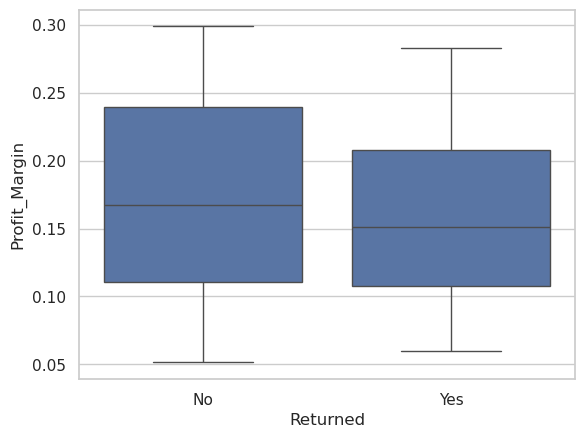

In [90]:
sns.boxplot(data=beng_temp,
            x='Returned',
            y='Profit_Margin')

In [91]:
beng_temp.groupby('Returned')['Profit_Margin'].agg(
    ['count', 'mean', 'median', 'std']
)

,count,mean,median,std
Returned,,,,
No,239,0.171989,0.167355,0.074867
Yes,21,0.155962,0.151324,0.067860


In [92]:
beng_temp[beng_temp['Returned'] == 'Yes']['Profit_Margin']

319     0.208062
1273    0.067976
1350    0.114225
1801    0.200097
2202    0.158779
2342    0.216942
3035    0.239982
3273    0.276220
3501    0.092121
4206    0.077732
4619    0.065639
4633    0.107624
4888    0.151324
5317    0.282968
5710    0.230199
6356    0.158335
6487    0.148378
6571    0.151463
7130    0.138444
7383    0.128760
7642    0.059930
Name: Profit_Margin, dtype: float64

In [93]:
mannwhitneyu(beng_temp[beng_temp['Returned'] == 'Yes']['Profit_Margin'], beng_temp[beng_temp['Returned'] == 'No']['Profit_Margin'], alternative='two-sided')

MannwhitneyuResult(statistic=np.float64(2216.0), pvalue=np.float64(0.37518251113556367))

## 4.3 Payment Mode Analysis

In [94]:
beng_temp.groupby('Payment_Mode')['Profit_Margin'].agg(
    ['count', 'mean', 'median', 'std']
)

,count,mean,median,std
Payment_Mode,,,,
Card,75,0.169646,0.168746,0.080112
Cash,93,0.170464,0.163386,0.062782
UPI,92,0.171783,0.159609,0.080746


<Axes: xlabel='Payment_Mode', ylabel='Profit_Margin'>

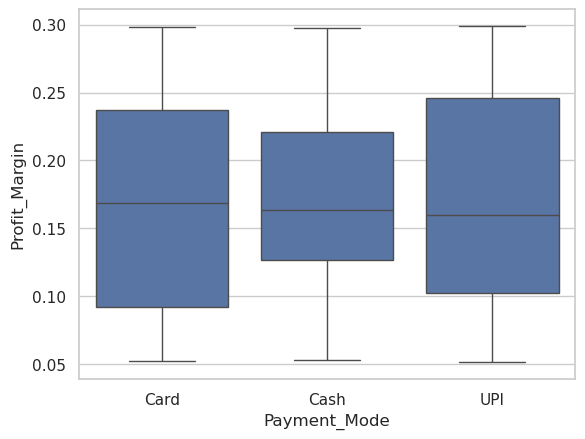

In [95]:
sns.boxplot(data=beng_temp,
            x='Payment_Mode',
            y='Profit_Margin')

In [96]:
from scipy.stats import kruskal
kruskal(beng_temp[beng_temp['Payment_Mode']=='Card']['Profit_Margin'],beng_temp[beng_temp['Payment_Mode']=='Cash']['Profit_Margin'],beng_temp[beng_temp['Payment_Mode']=='UPI']['Profit_Margin'])       

KruskalResult(statistic=np.float64(0.019398396748783853), pvalue=np.float64(0.9903476871437396))

In [97]:
store=beng_temp.groupby('Store_ID').agg({
   'Sales' : ['sum'],
    'Profit': ['sum'],
    'Payment_Mode':['count']})

In [98]:
store.columns=['_'.join(col) for col in store.columns]

In [99]:
store

,Sales_sum,Profit_sum,Payment_Mode_count
Store_ID,,,
S001,358726.86,55687.49,33
S002,240546.68,38334.56,23
S003,251412.08,44295.44,24
S004,260170.31,40692.20,26
S005,247353.55,47109.64,27
S006,230135.30,41175.09,24
S007,308015.58,52352.12,34
S008,179067.71,25405.36,23
S009,226492.50,36530.74,28


In [100]:
store['Profit_margin']=store['Profit_sum']/store['Sales_sum']

In [101]:
store.columns=['Sales_sum',	'Profit_sum','transaction_count','Profit_margin']

In [102]:
store['Sales_contribution']=(store['Sales_sum']/store['Sales_sum'].sum())*100

In [103]:
store

,Sales_sum,Profit_sum,transaction_count,Profit_margin,Sales_contribution
Store_ID,,,,,
S001,358726.86,55687.49,33,0.155236,14.217271
S002,240546.68,38334.56,23,0.159364,9.533486
S003,251412.08,44295.44,24,0.176187,9.964110
S004,260170.31,40692.20,26,0.156406,10.311221
S005,247353.55,47109.64,27,0.190455,9.803260
S006,230135.30,41175.09,24,0.178917,9.120856
S007,308015.58,52352.12,34,0.169966,12.207452
S008,179067.71,25405.36,23,0.141876,7.096916
S009,226492.50,36530.74,28,0.161289,8.976482


In [104]:
s001=beng_temp[beng_temp['Store_ID']=='S001']

In [105]:
s001_product=s001.groupby('Product_ID')[['Sales','Profit']].agg('sum')

In [106]:
s001_product['Profit_margin']=s001_product['Profit']/s001_product['Sales']*100

In [107]:
s001_product['Sales_contribution']=s001_product['Sales']/s001_product['Sales'].sum()*100

In [108]:
s001_product

,Sales,Profit,Profit_margin,Sales_contribution
Product_ID,,,,
P002,17574.75,1908.95,10.861890,4.899201
P010,7129.75,1791.06,25.120937,1.987515
P024,33454.98,5626.20,16.817227,9.326032
P027,20714.17,2908.66,14.041885,5.774357
P028,20062.23,3065.43,15.279608,5.592620
P029,15805.77,3065.54,19.395069,4.406074
P031,6600.08,1264.55,19.159616,1.839862
P035,3643.69,383.29,10.519281,1.015728
P044,17168.36,2861.05,16.664667,4.785914


In [109]:
beng_temp['Store_ID'].value_counts()

Store_ID
S007    34
S001    33
S009    28
S005    27
S004    26
S003    24
S006    24
S008    23
S002    23
S010    18
Name: count, dtype: int64

In [110]:
beng_temp.sample(20)

,Date,Store_ID,Store_City,Product_ID,Category,Customer_ID,Sales,Quantity,Profit,Discount,Payment_Mode,Returned,Profit_Margin
3724,2024-09-03,S003,Bengaluru,P114,Grocery,C0962,2218.56,7,551.50,5,Cash,No,0.248585
4828,2024-11-17,S007,Bengaluru,P023,Grocery,C0867,13726.24,5,3816.20,0,Card,No,0.278022
6827,2025-04-03,S002,Bengaluru,P095,Grocery,C0370,17524.38,5,1985.99,25,Cash,No,0.113327
1095,2024-03-16,S006,Bengaluru,P004,Grocery,C0245,17717.02,2,4163.48,15,Card,No,0.234999
1846,2024-05-06,S002,Bengaluru,P009,Grocery,C0360,7589.06,5,1124.68,0,Card,No,0.148198
4422,2024-10-20,S009,Bengaluru,P065,Grocery,C0637,5361.76,8,968.68,0,UPI,No,0.180665
6487,2025-03-10,S006,Bengaluru,P077,Grocery,C0735,1441.52,2,213.89,20,Card,Yes,0.148378
5570,2025-01-08,S005,Bengaluru,P059,Grocery,C0758,6104.05,4,1094.87,10,Cash,No,0.179368
4151,2024-10-02,S001,Bengaluru,P027,Grocery,C0815,20714.17,4,2908.66,10,Card,No,0.140419
781,2024-02-24,S001,Bengaluru,P047,Grocery,C0632,14281.76,6,2172.94,10,UPI,No,0.152148


## 4.4 Quantity Analysis

In [111]:
product=beng_temp.groupby(by=['Store_ID','Product_ID'])[['Sales','Profit','Quantity']].sum()

In [112]:
product['Profit_Margin']=(product['Profit']/product['Sales'])*100

In [113]:
product

Sales   Profit  Quantity  Profit_Margin
Store_ID Product_ID                                            
S001     P002        17574.75  1908.95         4      10.861890
         P010         7129.75  1791.06         8      25.120937
         P024        33454.98  5626.20        11      16.817227
         P027        20714.17  2908.66         4      14.041885
         P028        20062.23  3065.43         1      15.279608
...                       ...      ...       ...            ...
S010     P095         5364.73   699.13         7      13.031970
         P103        13863.86  2208.73         2      15.931566
         P104        21072.23  1199.68         6       5.693180
         P111         2230.24   479.23         5      21.487822
         P112         8013.10  1651.03         4      20.604136

[239 rows x 4 columns]

<Axes: xlabel='Store_ID', ylabel='Profit_Margin'>

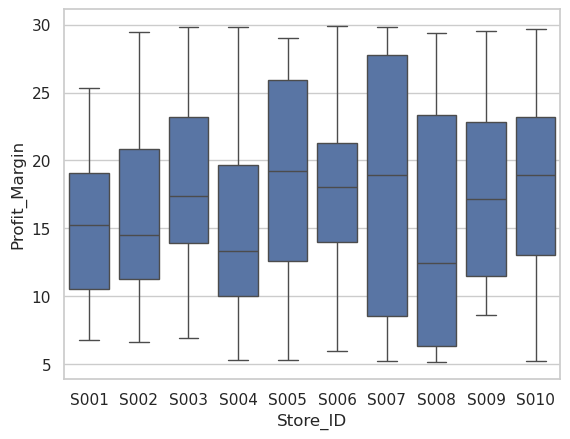

In [114]:
sns.boxplot(data=product,
            x='Store_ID',
            y='Profit_Margin')

In [116]:
s001_product

,Sales,Profit,Profit_margin,Sales_contribution
Product_ID,,,,
P002,17574.75,1908.95,10.861890,4.899201
P010,7129.75,1791.06,25.120937,1.987515
P024,33454.98,5626.20,16.817227,9.326032
P027,20714.17,2908.66,14.041885,5.774357
P028,20062.23,3065.43,15.279608,5.592620
P029,15805.77,3065.54,19.395069,4.406074
P031,6600.08,1264.55,19.159616,1.839862
P035,3643.69,383.29,10.519281,1.015728
P044,17168.36,2861.05,16.664667,4.785914


<function matplotlib.pyplot.show(close=None, block=None)>

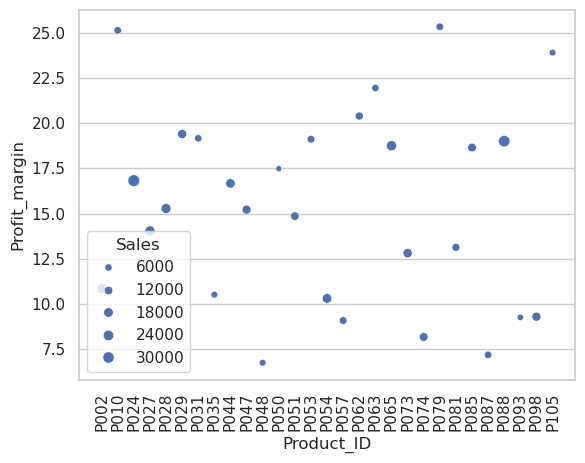

In [117]:
sns.scatterplot(data=s001_product,
               x='Product_ID',
y='Profit_margin',
size='Sales')

plt.xticks(rotation=90)


plt.show

<Axes: xlabel='Sales', ylabel='Profit_margin'>

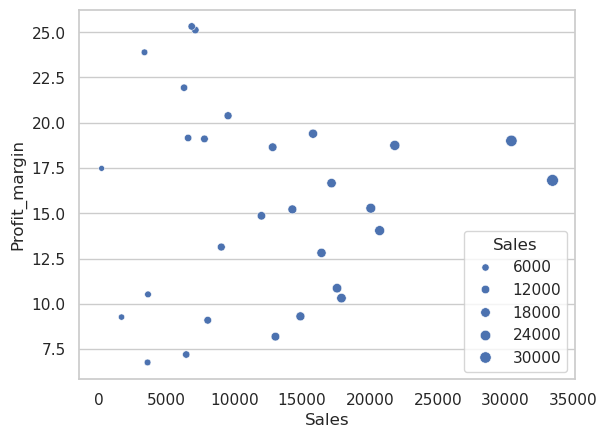

In [118]:
sns.scatterplot(data=s001_product,
               x='Sales',
y='Profit_margin',
size='Sales')

In [119]:
s001_product['Margin_Contribution'] = (s001_product['Profit'] / s001_product['Sales'].sum())*100

In [120]:
s001_product=s001_product.sort_values('Margin_Contribution', ascending=False)

In [121]:
s001_product.tail(5)

,Sales,Profit,Profit_margin,Sales_contribution,Margin_Contribution
Product_ID,,,,,
P087,6458.09,464.80,7.197174,1.800281,0.129569
P035,3643.69,383.29,10.519281,1.015728,0.106847
P048,3610.70,244.06,6.759354,1.006532,0.068035
P093,1691.43,156.72,9.265533,0.471509,0.043688
P050,224.49,39.24,17.479620,0.062580,0.010939


In [122]:
s001_product['Cumulative_Margin_Contribution'] = (
    s001_product['Margin_Contribution'].cumsum()
)

In [123]:
s001_product

,Sales,Profit,Profit_margin,Sales_contribution,Margin_Contribution,Cumulative_Margin_Contribution
Product_ID,,,,,,
P088,30423.62,5780.23,18.999153,8.480999,1.611318,1.611318
P024,33454.98,5626.20,16.817227,9.326032,1.568380,3.179698
P065,21831.65,4093.00,18.748010,6.085870,1.140980,4.320677
P029,15805.77,3065.54,19.395069,4.406074,0.854561,5.175238
P028,20062.23,3065.43,15.279608,5.592620,0.854530,6.029769
P027,20714.17,2908.66,14.041885,5.774357,0.810829,6.840597
P044,17168.36,2861.05,16.664667,4.785914,0.797557,7.638154
P085,12830.25,2392.74,18.649208,3.576607,0.667009,8.305163
P047,14281.76,2172.94,15.214791,3.981235,0.605737,8.910900


In [124]:
s001_product[
    ['Margin_Contribution', 'Cumulative_Margin_Contribution']
].head(10)

,Margin_Contribution,Cumulative_Margin_Contribution
Product_ID,,
P088,1.611318,1.611318
P024,1.568380,3.179698
P065,1.140980,4.320677
P029,0.854561,5.175238
P028,0.854530,6.029769
P027,0.810829,6.840597
P044,0.797557,7.638154
P085,0.667009,8.305163
P047,0.605737,8.910900


## 4.5 Store-Level Benchmark: S001 vs Other Stores

In [126]:
other_stores = product[product.index != 'S001']

In [127]:
other_avg = (
    other_stores
    .groupby('Product_ID')['Profit_Margin']
    .mean()
)

In [128]:
other_avg=other_avg.reset_index()

In [129]:
s001 = product.loc['S001']

In [130]:
s001.size

116

In [131]:
other_avg.size

218

In [132]:
common_products = s001.index.intersection(other_avg.index)

len(common_products)

0

In [133]:
print(s001.index)
print(other_avg.index[:10])

Index(['P002', 'P010', 'P024', 'P027', 'P028', 'P029', 'P031', 'P035', 'P044',
       'P047', 'P048', 'P050', 'P051', 'P053', 'P054', 'P057', 'P062', 'P063',
       'P065', 'P073', 'P074', 'P079', 'P081', 'P085', 'P087', 'P088', 'P093',
       'P098', 'P105'],
      dtype='str', name='Product_ID')
RangeIndex(start=0, stop=10, step=1)


In [134]:
other_avg = (
    product.loc[product.index != 'S001']
    .groupby('Product_ID')['Profit_Margin']
    .mean()
)

In [135]:
s001.index.intersection(other_avg.index)

Index(['P002', 'P010', 'P024', 'P027', 'P028', 'P029', 'P031', 'P035', 'P044',
       'P047', 'P048', 'P050', 'P051', 'P053', 'P054', 'P057', 'P062', 'P063',
       'P065', 'P073', 'P074', 'P079', 'P081', 'P085', 'P087', 'P088', 'P093',
       'P098', 'P105'],
      dtype='str', name='Product_ID')

In [136]:
s001_compare = s001.loc[
    s001.index.intersection(other_avg.index)
].copy()

s001_compare['Other_Avg_Margin'] = other_avg.loc[
    s001_compare.index
]

s001_compare['Margin_Difference'] = (
    s001_compare['Profit_Margin']
    - s001_compare['Other_Avg_Margin']
)

In [137]:
s001_compare.sort_values(
    'Margin_Difference'
).head(10)

,Sales,Profit,Quantity,Profit_Margin,Other_Avg_Margin,Margin_Difference
Product_ID,,,,,,
P073,16428.03,2104.64,4,12.811274,20.706794,-7.895519
P048,3610.70,244.06,7,6.759354,12.840588,-6.081233
P093,1691.43,156.72,7,9.265533,14.698782,-5.433249
P062,9542.33,1945.45,7,20.387578,24.473410,-4.085832
P074,13034.38,1066.80,7,8.184509,12.198963,-4.014454
P057,8045.13,731.33,7,9.090344,12.954905,-3.864561
P054,17899.76,1845.90,3,10.312429,13.648585,-3.336156
P087,6458.09,464.80,7,7.197174,9.963332,-2.766158
P047,14281.76,2172.94,6,15.214791,17.398278,-2.183487


In [138]:
(s001_compare['Margin_Difference'] < 0).sum()

np.int64(11)

## 4.6 Identifying Underperforming Products

In [139]:
problem_products=s001_compare[s001_compare['Margin_Difference'] < 0].index

In [140]:
problem_products

Index(['P047', 'P048', 'P051', 'P054', 'P057', 'P062', 'P073', 'P074', 'P087',
       'P093', 'P098'],
      dtype='str', name='Product_ID')

In [141]:
problem_df=beng_temp[beng_temp['Product_ID'].isin(problem_products)]

In [142]:
problem_df

,Date,Store_ID,Store_City,Product_ID,Category,Customer_ID,Sales,Quantity,Profit,Discount,Payment_Mode,Returned,Profit_Margin
151,2024-01-10,S010,Bengaluru,P073,Grocery,C0886,18168.95,5,5196.74,0,UPI,No,0.286023
781,2024-02-24,S001,Bengaluru,P047,Grocery,C0632,14281.76,6,2172.94,10,UPI,No,0.152148
882,2024-03-02,S010,Bengaluru,P047,Grocery,C0304,22281.24,3,4217.90,20,Card,No,0.189303
1018,2024-03-11,S001,Bengaluru,P057,Grocery,C0876,8045.13,7,731.33,20,Cash,No,0.090903
1250,2024-03-27,S001,Bengaluru,P073,Grocery,C0745,16428.03,4,2104.64,25,Cash,No,0.128113
1303,2024-03-31,S001,Bengaluru,P051,Grocery,C0578,12003.76,8,1783.81,10,Cash,No,0.148604
1765,2024-04-30,S001,Bengaluru,P048,Grocery,C0355,3610.70,7,244.06,25,Card,No,0.067594
1849,2024-05-06,S002,Bengaluru,P054,Grocery,C0523,16206.41,5,2347.96,20,Cash,No,0.144878
1974,2024-05-14,S007,Bengaluru,P048,Grocery,C0768,14966.53,1,2831.94,0,UPI,No,0.189218
2113,2024-05-22,S009,Bengaluru,P062,Grocery,C0187,621.27,6,177.43,15,Cash,No,0.285592


In [143]:
problem_df.groupby('Store_ID')['Discount'].mean()

Store_ID
S001    13.181818
S002    20.000000
S003    17.500000
S004     5.000000
S005    22.500000
S006     5.000000
S007    10.000000
S008    17.500000
S009    12.500000
S010    13.750000
Name: Discount, dtype: float64

In [144]:
problem_df['Weighted_Discount_Value'] = (
    problem_df['Sales'] * problem_df['Discount']
)

In [145]:
weighted_discount = (
    problem_df.groupby('Store_ID')['Weighted_Discount_Value'].sum()
    / problem_df.groupby('Store_ID')['Sales'].sum()
)

In [146]:
weighted_discount

Store_ID
S001    14.201681
S002    20.000000
S003    17.578600
S004     7.022929
S005    22.086984
S006     5.000000
S007    11.374645
S008    18.238913
S009    11.101750
S010    12.349766
dtype: float64

In [147]:
problem_df.groupby('Store_ID')['Returned'].value_counts()


Store_ID  Returned
S001      No          11
S002      No           1
S003      No           2
S004      No           3
S005      No           2
S006      No           1
S007      No           2
S008      No           2
S009      No           2
S010      No           4
Name: count, dtype: int64

In [148]:
problem_df['Unit_Price'] = (
    problem_df['Sales'] / problem_df['Quantity']
)

In [149]:
problem_df[
    problem_df['Product_ID'] == 'P073'
].groupby('Store_ID')['Unit_Price'].mean()

Store_ID
S001    4107.0075
S010    3633.7900
Name: Unit_Price, dtype: float64

In [150]:
problem_df['Cost'] = (
    problem_df['Sales'] - problem_df['Profit']
)


In [151]:
problem_df['Cost_Per_Unit'] = (
    problem_df['Cost'] / problem_df['Quantity']
)

In [152]:
problem_df[
    problem_df['Product_ID'] == 'P073'
].groupby('Store_ID')['Cost_Per_Unit'].mean()

Store_ID
S001    3580.8475
S010    2594.4420
Name: Cost_Per_Unit, dtype: float64

## 4.7 Cost Comparison

In [153]:
product['Cost']=product['Sales']-product['Profit']

In [154]:
product['Cost_per_unit']=product['Cost']/product['Quantity']

In [155]:
product

Sales   Profit  Quantity  Profit_Margin      Cost  \
Store_ID Product_ID                                                         
S001     P002        17574.75  1908.95         4      10.861890  15665.80   
         P010         7129.75  1791.06         8      25.120937   5338.69   
         P024        33454.98  5626.20        11      16.817227  27828.78   
         P027        20714.17  2908.66         4      14.041885  17805.51   
         P028        20062.23  3065.43         1      15.279608  16996.80   
...                       ...      ...       ...            ...       ...   
S010     P095         5364.73   699.13         7      13.031970   4665.60   
         P103        13863.86  2208.73         2      15.931566  11655.13   
         P104        21072.23  1199.68         6       5.693180  19872.55   
         P111         2230.24   479.23         5      21.487822   1751.01   
         P112         8013.10  1651.03         4      20.604136   6362.07   

                     Cost_per_unit  
Store_ID Product_ID                 
S001     P002          3916.450000  
         P010           667.336250  
         P024          2529.889091  
         P027          4451.377500  
         P028         16996.800000  
...                            ...  
S010     P095           666.514286  
         P103          5827.565000  
         P104          3312.091667  
         P111           350.202000  
         P112          1590.517500  

[239 rows x 6 columns]

In [156]:
product[product.index.isin(problem_products, level='Product_ID')]

Sales   Profit  Quantity  Profit_Margin      Cost  \
Store_ID Product_ID                                                         
S001     P047        14281.76  2172.94         6      15.214791  12108.82   
         P048         3610.70   244.06         7       6.759354   3366.64   
         P051        12003.76  1783.81         8      14.860427  10219.95   
         P054        17899.76  1845.90         3      10.312429  16053.86   
         P057         8045.13   731.33         7       9.090344   7313.80   
         P062         9542.33  1945.45         7      20.387578   7596.88   
         P073        16428.03  2104.64         4      12.811274  14323.39   
         P074        13034.38  1066.80         7       8.184509  11967.58   
         P087         6458.09   464.80         7       7.197174   5993.29   
         P093         1691.43   156.72         7       9.265533   1534.71   
         P098        14874.48  1384.21         6       9.305939  13490.27   
S002     P054        16206.41  2347.96         5      14.487848  13858.45   
S003     P051        10093.44  1892.08         8      18.745641   8201.36   
         P057        10307.24   814.88         5       7.905899   9492.36   
S004     P054        14031.67  1651.89         1      11.772583  12379.78   
         P057        11039.47   611.48         8       5.539034  10427.99   
         P098         2768.25   326.01         7      11.776754   2442.24   
S005     P054         4141.12  1098.59         6      26.528813   3042.53   
         P074         2966.84   682.96         1      23.019779   2283.88   
S006     P093         9920.41  1997.18         7      20.132031   7923.23   
S007     P048        14966.53  2831.94         1      18.921821  12134.59   
         P074        19737.04  1064.34         4       5.392602  18672.70   
S008     P054         1523.17    78.31         6       5.141251   1444.86   
         P057          828.19   242.53         5      29.284343    585.66   
S009     P047         2198.20   396.77         7      18.049768   1801.43   
         P062          621.27   177.43         6      28.559242    443.84   
S010     P047        22281.24  4217.90         3      18.930275  18063.34   
         P073        18168.95  5196.74         5      28.602313  12972.21   
         P087         9239.49  1176.14        13      12.729490   8063.35   

                     Cost_per_unit  
Store_ID Product_ID                 
S001     P047          2018.136667  
         P048           480.948571  
         P051          1277.493750  
         P054          5351.286667  
         P057          1044.828571  
         P062          1085.268571  
         P073          3580.847500  
         P074          1709.654286  
         P087           856.184286  
         P093           219.244286  
         P098          2248.378333  
S002     P054          2771.690000  
S003     P051          1025.170000  
         P057          1898.472000  
S004     P054         12379.780000  
         P057          1303.498750  
         P098           348.891429  
S005     P054           507.088333  
         P074          2283.880000  
S006     P093          1131.890000  
S007     P048         12134.590000  
         P074          4668.175000  
S008     P054           240.810000  
         P057           117.132000  
S009     P047           257.347143  
         P062            73.973333  
S010     P047          6021.113333  
         P073          2594.442000  
         P087           620.257692

In [157]:
other_prod=product[product.index.get_level_values(0) != 'S001']

In [158]:
other_avg_prod=other_prod.groupby('Product_ID')['Cost_per_unit'].mean()

In [159]:
other_avg_prod

Product_ID
P001    13133.300000
P003     1531.767000
P004     4243.256429
P006     3724.917500
P007     1363.032000
            ...     
P114     1673.533254
P115      162.476250
P117     3140.493542
P118      763.732857
P120      613.594625
Name: Cost_per_unit, Length: 106, dtype: float64

In [160]:
other_prod

Sales   Profit  Quantity  Profit_Margin      Cost  \
Store_ID Product_ID                                                         
S002     P003         6696.98  1719.11         3      25.669929   4977.87   
         P009         7589.06  1124.68         5      14.819754   6464.38   
         P011         2000.48   550.29         7      27.507898   1450.19   
         P016        15389.47  1417.69         7       9.212078  13971.78   
         P024         8305.49   645.60         4       7.773172   7659.89   
...                       ...      ...       ...            ...       ...   
S010     P095         5364.73   699.13         7      13.031970   4665.60   
         P103        13863.86  2208.73         2      15.931566  11655.13   
         P104        21072.23  1199.68         6       5.693180  19872.55   
         P111         2230.24   479.23         5      21.487822   1751.01   
         P112         8013.10  1651.03         4      20.604136   6362.07   

                     Cost_per_unit  
Store_ID Product_ID                 
S002     P003          1659.290000  
         P009          1292.876000  
         P011           207.170000  
         P016          1995.968571  
         P024          1914.972500  
...                            ...  
S010     P095           666.514286  
         P103          5827.565000  
         P104          3312.091667  
         P111           350.202000  
         P112          1590.517500  

[210 rows x 6 columns]

In [161]:
product.index.intersection(other_avg_prod.index)

MultiIndex([], )

In [162]:
s001_product = product.xs('S001', level='Store_ID')

In [163]:
common_products = s001_product.index.intersection(
    other_avg_prod.index
)

In [164]:
common_products

Index(['P010', 'P024', 'P028', 'P029', 'P031', 'P035', 'P044', 'P047', 'P048',
       'P050', 'P051', 'P053', 'P054', 'P057', 'P062', 'P063', 'P065', 'P073',
       'P074', 'P079', 'P081', 'P087', 'P088', 'P093', 'P098', 'P105'],
      dtype='str', name='Product_ID')

In [165]:
len(common_products)

26

In [166]:
cost_compare = s001_product.loc[common_products].copy()

In [167]:
cost_compare['Other_Avg_Cost'] = other_avg_prod.loc[common_products]

In [168]:
cost_compare

,Sales,Profit,Quantity,Profit_Margin,Cost,Cost_per_unit,Other_Avg_Cost
Product_ID,,,,,,,
P010,7129.75,1791.06,8,25.120937,5338.69,667.336250,4468.338687
P024,33454.98,5626.20,11,16.817227,27828.78,2529.889091,1978.494833
P028,20062.23,3065.43,1,15.279608,16996.80,16996.800000,2509.798333
P029,15805.77,3065.54,13,19.395069,12740.23,980.017692,10767.996000
P031,6600.08,1264.55,7,19.159616,5335.53,762.218571,1384.209266
P035,3643.69,383.29,2,10.519281,3260.40,1630.200000,790.443667
P044,17168.36,2861.05,9,16.664667,14307.31,1589.701111,1026.483333
P047,14281.76,2172.94,6,15.214791,12108.82,2018.136667,3139.230238
P048,3610.70,244.06,7,6.759354,3366.64,480.948571,12134.590000


In [169]:
Cost_difference=s001_product['Cost_per_unit']-cost_compare['Cost_per_unit']

In [170]:
cost_compare['Other_Avg_Cost'] = (
    other_avg_prod.loc[common_products]
)

In [171]:
cost_compare

,Sales,Profit,Quantity,Profit_Margin,Cost,Cost_per_unit,Other_Avg_Cost
Product_ID,,,,,,,
P010,7129.75,1791.06,8,25.120937,5338.69,667.336250,4468.338687
P024,33454.98,5626.20,11,16.817227,27828.78,2529.889091,1978.494833
P028,20062.23,3065.43,1,15.279608,16996.80,16996.800000,2509.798333
P029,15805.77,3065.54,13,19.395069,12740.23,980.017692,10767.996000
P031,6600.08,1264.55,7,19.159616,5335.53,762.218571,1384.209266
P035,3643.69,383.29,2,10.519281,3260.40,1630.200000,790.443667
P044,17168.36,2861.05,9,16.664667,14307.31,1589.701111,1026.483333
P047,14281.76,2172.94,6,15.214791,12108.82,2018.136667,3139.230238
P048,3610.70,244.06,7,6.759354,3366.64,480.948571,12134.590000


In [172]:
cost_compare['cost_difference']=cost_compare['Cost_per_unit']-cost_compare['Other_Avg_Cost']

In [173]:
cost_compare

,Sales,Profit,Quantity,Profit_Margin,Cost,Cost_per_unit,Other_Avg_Cost,cost_difference
Product_ID,,,,,,,,
P010,7129.75,1791.06,8,25.120937,5338.69,667.336250,4468.338687,-3801.002437
P024,33454.98,5626.20,11,16.817227,27828.78,2529.889091,1978.494833,551.394258
P028,20062.23,3065.43,1,15.279608,16996.80,16996.800000,2509.798333,14487.001667
P029,15805.77,3065.54,13,19.395069,12740.23,980.017692,10767.996000,-9787.978308
P031,6600.08,1264.55,7,19.159616,5335.53,762.218571,1384.209266,-621.990694
P035,3643.69,383.29,2,10.519281,3260.40,1630.200000,790.443667,839.756333
P044,17168.36,2861.05,9,16.664667,14307.31,1589.701111,1026.483333,563.217778
P047,14281.76,2172.94,6,15.214791,12108.82,2018.136667,3139.230238,-1121.093571
P048,3610.70,244.06,7,6.759354,3366.64,480.948571,12134.590000,-11653.641429


In [174]:
cost_compare.shape

(26, 8)

In [175]:
beng_temp.shape

(260, 13)

In [176]:
problem_products

Index(['P047', 'P048', 'P051', 'P054', 'P057', 'P062', 'P073', 'P074', 'P087',
       'P093', 'P098'],
      dtype='str', name='Product_ID')

In [177]:
product.columns

Index(['Sales', 'Profit', 'Quantity', 'Profit_Margin', 'Cost',
       'Cost_per_unit'],
      dtype='str')

## 4.8 Price Comparison

In [178]:
product['Unit_Price'] = product['Sales'] / product['Quantity']

In [179]:
unit_temp = product[
    product.index.get_level_values('Store_ID') != 'S001'
]

In [180]:
other_avg_price = unit_temp.groupby('Product_ID')['Unit_Price'].mean()

In [181]:
s001_product = product.xs('S001', level='Store_ID')

In [182]:
price_compare = s001_product.loc[common_products].copy()

In [183]:
price_compare['Other_Avg_Price'] = (
    other_avg_price.loc[common_products]
)

In [184]:
price_compare.head()

,Sales,Profit,Quantity,Profit_Margin,Cost,Cost_per_unit,Unit_Price,Other_Avg_Price
Product_ID,,,,,,,,
P010,7129.75,1791.06,8,25.120937,5338.69,667.336250,891.218750,4861.664813
P024,33454.98,5626.20,11,16.817227,27828.78,2529.889091,3041.361818,2246.526000
P028,20062.23,3065.43,1,15.279608,16996.80,16996.800000,20062.230000,2833.786667
P029,15805.77,3065.54,13,19.395069,12740.23,980.017692,1215.828462,12477.528000
P031,6600.08,1264.55,7,19.159616,5335.53,762.218571,942.868571,1685.429365


In [185]:
price_compare['Price_Difference'] = (
    price_compare['Unit_Price']
    - price_compare['Other_Avg_Price']
)

In [186]:
price_problem = price_compare[
    price_compare.index.isin(problem_products)
]

In [187]:
price_problem

,Sales,Profit,Quantity,Profit_Margin,Cost,Cost_per_unit,Unit_Price,Other_Avg_Price,Price_Difference
Product_ID,,,,,,,,,
P047,14281.76,2172.94,6,15.214791,12108.82,2018.136667,2380.293333,3870.554286,-1490.260952
P048,3610.70,244.06,7,6.759354,3366.64,480.948571,515.814286,14966.530000,-14450.715714
P051,12003.76,1783.81,8,14.860427,10219.95,1277.493750,1500.470000,1261.680000,238.790000
P054,17899.76,1845.90,3,10.312429,16053.86,5351.286667,5966.586667,4554.250083,1412.336583
P057,8045.13,731.33,7,9.090344,7313.80,1044.828571,1149.304286,1202.339917,-53.035631
P062,9542.33,1945.45,7,20.387578,7596.88,1085.268571,1363.190000,103.545000,1259.645000
P073,16428.03,2104.64,4,12.811274,14323.39,3580.847500,4107.007500,3633.790000,473.217500
P074,13034.38,1066.80,7,8.184509,11967.58,1709.654286,1862.054286,3950.550000,-2088.495714
P087,6458.09,464.80,7,7.197174,5993.29,856.184286,922.584286,710.730000,211.854286


## 4.9 Initial Margin, Price & Cost Comparison

In [188]:
final_compare = s001_compare.loc[
    problem_products,
    ['Margin_Difference']
].copy()

In [189]:
final_compare['Price_Difference'] = price_problem['Price_Difference']
final_compare['Cost_Difference'] = cost_compare['cost_difference']

In [190]:
final_compare

,Margin_Difference,Price_Difference,Cost_Difference
Product_ID,,,
P047,-2.183487,-1490.260952,-1121.093571
P048,-6.081233,-14450.715714,-11653.641429
P051,-1.942607,238.790000,252.323750
P054,-3.336156,1412.336583,1376.444583
P057,-3.864561,-53.035631,-61.539012
P062,-4.085832,1259.645000,1011.295238
P073,-7.895519,473.217500,986.405500
P074,-4.014454,-2088.495714,-1766.373214
P087,-2.766158,211.854286,235.926593


In [191]:
final_compare.corr()

,Margin_Difference,Price_Difference,Cost_Difference
Margin_Difference,1.000000,0.401585,0.375698
Price_Difference,0.401585,1.000000,0.998819
Cost_Difference,0.375698,0.998819,1.000000


In [192]:
final_compare.sort_values('Margin_Difference')

,Margin_Difference,Price_Difference,Cost_Difference
Product_ID,,,
P073,-7.895519,473.217500,986.405500
P048,-6.081233,-14450.715714,-11653.641429
P093,-5.433249,-1175.568571,-912.645714
P062,-4.085832,1259.645000,1011.295238
P074,-4.014454,-2088.495714,-1766.373214
P057,-3.864561,-53.035631,-61.539012
P054,-3.336156,1412.336583,1376.444583
P087,-2.766158,211.854286,235.926593
P047,-2.183487,-1490.260952,-1121.093571


In [193]:
final_compare

,Margin_Difference,Price_Difference,Cost_Difference
Product_ID,,,
P047,-2.183487,-1490.260952,-1121.093571
P048,-6.081233,-14450.715714,-11653.641429
P051,-1.942607,238.790000,252.323750
P054,-3.336156,1412.336583,1376.444583
P057,-3.864561,-53.035631,-61.539012
P062,-4.085832,1259.645000,1011.295238
P073,-7.895519,473.217500,986.405500
P074,-4.014454,-2088.495714,-1766.373214
P087,-2.766158,211.854286,235.926593


In [194]:
s001_compare.loc['P073']

Sales                16428.030000
Profit                2104.640000
Quantity                 4.000000
Profit_Margin           12.811274
Other_Avg_Margin        20.706794
Margin_Difference       -7.895519
Name: P073, dtype: float64

In [195]:
price_problem.loc['P073']

Sales               16428.030000
Profit               2104.640000
Quantity                4.000000
Profit_Margin          12.811274
Cost                14323.390000
Cost_per_unit        3580.847500
Unit_Price           4107.007500
Other_Avg_Price      3633.790000
Price_Difference      473.217500
Name: P073, dtype: float64

In [196]:
cost_compare.loc['P073']

Sales              16428.030000
Profit              2104.640000
Quantity               4.000000
Profit_Margin         12.811274
Cost               14323.390000
Cost_per_unit       3580.847500
Other_Avg_Cost      2594.442000
cost_difference      986.405500
Name: P073, dtype: float64

In [197]:
final_compare['Price_vs_Cost'] = (
    final_compare['Price_Difference']
    - final_compare['Cost_Difference']
)

In [198]:
final_compare.sort_values('Margin_Difference')

,Margin_Difference,Price_Difference,Cost_Difference,Price_vs_Cost
Product_ID,,,,
P073,-7.895519,473.217500,986.405500,-513.188000
P048,-6.081233,-14450.715714,-11653.641429,-2797.074286
P093,-5.433249,-1175.568571,-912.645714,-262.922857
P062,-4.085832,1259.645000,1011.295238,248.349762
P074,-4.014454,-2088.495714,-1766.373214,-322.122500
P057,-3.864561,-53.035631,-61.539012,8.503381
P054,-3.336156,1412.336583,1376.444583,35.892000
P087,-2.766158,211.854286,235.926593,-24.072308
P047,-2.183487,-1490.260952,-1121.093571,-369.167381


In [199]:
s001_compare.loc[
    ['P062', 'P054', 'P098']
]

,Sales,Profit,Quantity,Profit_Margin,Other_Avg_Margin,Margin_Difference
Product_ID,,,,,,
P062,9542.33,1945.45,7,20.387578,24.473410,-4.085832
P054,17899.76,1845.90,3,10.312429,13.648585,-3.336156
P098,14874.48,1384.21,6,9.305939,10.541347,-1.235408


In [200]:
price_problem.loc[['P062', 'P054', 'P098']]

,Sales,Profit,Quantity,Profit_Margin,Cost,Cost_per_unit,Unit_Price,Other_Avg_Price,Price_Difference
Product_ID,,,,,,,,,
P062,9542.33,1945.45,7,20.387578,7596.88,1085.268571,1363.190000,103.545000,1259.645000
P054,17899.76,1845.90,3,10.312429,16053.86,5351.286667,5966.586667,4554.250083,1412.336583
P098,14874.48,1384.21,6,9.305939,13490.27,2248.378333,2479.080000,395.464286,2083.615714


In [201]:
cost_compare.loc[['P062', 'P054', 'P098']]

,Sales,Profit,Quantity,Profit_Margin,Cost,Cost_per_unit,Other_Avg_Cost,cost_difference
Product_ID,,,,,,,,
P062,9542.33,1945.45,7,20.387578,7596.88,1085.268571,73.973333,1011.295238
P054,17899.76,1845.90,3,10.312429,16053.86,5351.286667,3974.842083,1376.444583
P098,14874.48,1384.21,6,9.305939,13490.27,2248.378333,348.891429,1899.486905


## 4.10 Cost-to-Sales Investigation & Validation

In [203]:
product['cost_to_sales']=product['Cost']/product['Sales']

In [204]:
other_avg_sales_cost= product.loc [product.index.get_level_values(0) != 'S001'].groupby('Product_ID')[['cost_to_sales']].mean()

In [205]:
other_avg_sales_cost

,cost_to_sales
Product_ID,
P001,0.883415
P003,0.810617
P004,0.743338
P006,0.819788
P007,0.845016
...,...
P114,0.748976
P115,0.702042
P117,0.832753


In [206]:
s001

,Sales,Profit,Quantity,Profit_Margin
Product_ID,,,,
P002,17574.75,1908.95,4,10.861890
P010,7129.75,1791.06,8,25.120937
P024,33454.98,5626.20,11,16.817227
P027,20714.17,2908.66,4,14.041885
P028,20062.23,3065.43,1,15.279608
P029,15805.77,3065.54,13,19.395069
P031,6600.08,1264.55,7,19.159616
P035,3643.69,383.29,2,10.519281
P044,17168.36,2861.05,9,16.664667


In [208]:
s001_costs = product['Cost'].xs('S001', level=0)


In [209]:
s001['Cost']=s001_costs

In [210]:
s001['cost-to-sales']=s001['Cost']/s001['Sales']

In [211]:
s001

,Sales,Profit,Quantity,Profit_Margin,Cost,cost-to-sales
Product_ID,,,,,,
P002,17574.75,1908.95,4,10.861890,15665.80,0.891381
P010,7129.75,1791.06,8,25.120937,5338.69,0.748791
P024,33454.98,5626.20,11,16.817227,27828.78,0.831828
P027,20714.17,2908.66,4,14.041885,17805.51,0.859581
P028,20062.23,3065.43,1,15.279608,16996.80,0.847204
P029,15805.77,3065.54,13,19.395069,12740.23,0.806049
P031,6600.08,1264.55,7,19.159616,5335.53,0.808404
P035,3643.69,383.29,2,10.519281,3260.40,0.894807
P044,17168.36,2861.05,9,16.664667,14307.31,0.833353


In [212]:
other_avg_sales_cost

,cost_to_sales
Product_ID,
P001,0.883415
P003,0.810617
P004,0.743338
P006,0.819788
P007,0.845016
...,...
P114,0.748976
P115,0.702042
P117,0.832753


In [213]:
problem_products

Index(['P047', 'P048', 'P051', 'P054', 'P057', 'P062', 'P073', 'P074', 'P087',
       'P093', 'P098'],
      dtype='str', name='Product_ID')

In [214]:
cost_to_sales=other_avg_sales_cost[other_avg_sales_cost.index.isin(problem_products)]

In [215]:
cost_to_sales=cost_to_sales.reset_index()

In [216]:
cost_to_sales=cost_to_sales.set_index('Product_ID')

In [217]:
cost_to_sales.columns=['Other_Cost_to_Sales']

In [218]:
cost_to_sales['S001_Cost_to_Sales']=s001['cost-to-sales']

In [219]:
cost_to_sales

,Other_Cost_to_Sales,S001_Cost_to_Sales
Product_ID,,
P047,0.815100,0.847852
P048,0.810782,0.932406
P051,0.812544,0.851396
P054,0.855174,0.896876
P057,0.857569,0.909097
P062,0.714408,0.796124
P073,0.713977,0.871887
P074,0.857938,0.918155
P087,0.872705,0.928028


In [220]:
cost_to_sales['differnce']=cost_to_sales['S001_Cost_to_Sales']-cost_to_sales['Other_Cost_to_Sales']

In [222]:
product

Sales   Profit  Quantity  Profit_Margin      Cost  \
Store_ID Product_ID                                                         
S001     P002        17574.75  1908.95         4      10.861890  15665.80   
         P010         7129.75  1791.06         8      25.120937   5338.69   
         P024        33454.98  5626.20        11      16.817227  27828.78   
         P027        20714.17  2908.66         4      14.041885  17805.51   
         P028        20062.23  3065.43         1      15.279608  16996.80   
...                       ...      ...       ...            ...       ...   
S010     P095         5364.73   699.13         7      13.031970   4665.60   
         P103        13863.86  2208.73         2      15.931566  11655.13   
         P104        21072.23  1199.68         6       5.693180  19872.55   
         P111         2230.24   479.23         5      21.487822   1751.01   
         P112         8013.10  1651.03         4      20.604136   6362.07   

                     Cost_per_unit    Unit_Price  cost_to_sales  
Store_ID Product_ID                                              
S001     P002          3916.450000   4393.687500       0.891381  
         P010           667.336250    891.218750       0.748791  
         P024          2529.889091   3041.361818       0.831828  
         P027          4451.377500   5178.542500       0.859581  
         P028         16996.800000  20062.230000       0.847204  
...                            ...           ...            ...  
S010     P095           666.514286    766.390000       0.869680  
         P103          5827.565000   6931.930000       0.840684  
         P104          3312.091667   3512.038333       0.943068  
         P111           350.202000    446.048000       0.785122  
         P112          1590.517500   2003.275000       0.793959  

[239 rows x 8 columns]

In [223]:
p073_data = product.xs('P073', level=1)



In [224]:
p073_remaining_stores = p073_data[p073_data.index != 'S001']

In [225]:
p073_remaining_stores

,Sales,Profit,Quantity,Profit_Margin,Cost,Cost_per_unit,Unit_Price,cost_to_sales
Store_ID,,,,,,,,
S010,18168.95,5196.74,5,28.602313,12972.21,2594.442,3633.79,0.713977


### Corrected Store Benchmark

In [226]:
correct_other_avg = (
    product[product.index.get_level_values(0) != 'S001']
    .groupby('Product_ID')['Profit_Margin']
    .mean()
).reset_index()

In [227]:
correct_other_avg=correct_other_avg.set_index('Product_ID')

In [228]:
correct_other_avg.loc['P073']

Profit_Margin    28.602313
Name: P073, dtype: float64

In [229]:
correct_other_avg.shape

(106, 1)

In [230]:
s001

,Sales,Profit,Quantity,Profit_Margin,Cost,cost-to-sales
Product_ID,,,,,,
P002,17574.75,1908.95,4,10.861890,15665.80,0.891381
P010,7129.75,1791.06,8,25.120937,5338.69,0.748791
P024,33454.98,5626.20,11,16.817227,27828.78,0.831828
P027,20714.17,2908.66,4,14.041885,17805.51,0.859581
P028,20062.23,3065.43,1,15.279608,16996.80,0.847204
P029,15805.77,3065.54,13,19.395069,12740.23,0.806049
P031,6600.08,1264.55,7,19.159616,5335.53,0.808404
P035,3643.69,383.29,2,10.519281,3260.40,0.894807
P044,17168.36,2861.05,9,16.664667,14307.31,0.833353


In [231]:
common_products=s001.index.intersection(correct_other_avg.index)

In [232]:
margin_diff=s001.loc[common_products,'Profit_Margin'].reset_index()

In [233]:
margin_diff=margin_diff.set_index('Product_ID')

In [234]:
margin_diff.columns=['s001_Profit_Margin']

In [235]:
margin_diff['common_Profit_Margin']=correct_other_avg.loc[common_products]

In [236]:
margin_diff.loc['P073']

s001_Profit_Margin      12.811274
common_Profit_Margin    28.602313
Name: P073, dtype: float64

In [237]:
margin_diff['Margin_Difference'] = (
    margin_diff['s001_Profit_Margin']
    - margin_diff['common_Profit_Margin']
)

In [238]:
margin_diff

,s001_Profit_Margin,common_Profit_Margin,Margin_Difference
Product_ID,,,
P010,25.120937,10.461270,14.659667
P024,16.817227,10.390055,6.427172
P028,15.279608,11.433053,3.846554
P029,19.395069,18.539430,0.855639
P031,19.159616,17.393353,1.766263
P035,10.519281,6.774215,3.745066
P044,16.664667,14.314771,2.349895
P047,15.214791,18.490021,-3.275230
P048,6.759354,18.921821,-12.162467


In [239]:
negative_md=margin_diff[margin_diff['Margin_Difference'] < 0].sort_values(by='Margin_Difference')

In [240]:
common_products

Index(['P010', 'P024', 'P028', 'P029', 'P031', 'P035', 'P044', 'P047', 'P048',
       'P050', 'P051', 'P053', 'P054', 'P057', 'P062', 'P063', 'P065', 'P073',
       'P074', 'P079', 'P081', 'P087', 'P088', 'P093', 'P098', 'P105'],
      dtype='str', name='Product_ID')

In [241]:
camparison_products=common_products.intersection(negative_md.index)

In [242]:
camparison_products

Index(['P047', 'P048', 'P051', 'P054', 'P057', 'P062', 'P073', 'P074', 'P087',
       'P093', 'P098'],
      dtype='str', name='Product_ID')

In [243]:
mask=product[product.index.get_level_values(1).isin(camparison_products)]

In [244]:
mask=mask[['Profit_Margin','Unit_Price', 'Cost_per_unit']]

In [245]:
mask

Profit_Margin    Unit_Price  Cost_per_unit
Store_ID Product_ID                                            
S001     P047            15.214791   2380.293333    2018.136667
         P048             6.759354    515.814286     480.948571
         P051            14.860427   1500.470000    1277.493750
         P054            10.312429   5966.586667    5351.286667
         P057             9.090344   1149.304286    1044.828571
         P062            20.387578   1363.190000    1085.268571
         P073            12.811274   4107.007500    3580.847500
         P074             8.184509   1862.054286    1709.654286
         P087             7.197174    922.584286     856.184286
         P093             9.265533    241.632857     219.244286
         P098             9.305939   2479.080000    2248.378333
S002     P054            14.487848   3241.282000    2771.690000
S003     P051            18.745641   1261.680000    1025.170000
         P057             7.905899   2061.448000    1898.472000
S004     P054            11.772583  14031.670000   12379.780000
         P057             5.539034   1379.933750    1303.498750
         P098            11.776754    395.464286     348.891429
S005     P054            26.528813    690.186667     507.088333
         P074            23.019779   2966.840000    2283.880000
S006     P093            20.132031   1417.201429    1131.890000
S007     P048            18.921821  14966.530000   12134.590000
         P074             5.392602   4934.260000    4668.175000
S008     P054             5.141251    253.861667     240.810000
         P057            29.284343    165.638000     117.132000
S009     P047            18.049768    314.028571     257.347143
         P062            28.559242    103.545000      73.973333
S010     P047            18.930275   7427.080000    6021.113333
         P073            28.602313   3633.790000    2594.442000
         P087            12.729490    710.730000     620.257692

In [246]:
not_s001=mask[mask.index.get_level_values(0) != 'S001']

In [247]:
not_s001=not_s001[[ 'Unit_Price' , 'Cost_per_unit','Profit_Margin']]

In [248]:
not_s001

Unit_Price  Cost_per_unit  Profit_Margin
Store_ID Product_ID                                            
S002     P054         3241.282000    2771.690000      14.487848
S003     P051         1261.680000    1025.170000      18.745641
         P057         2061.448000    1898.472000       7.905899
S004     P054        14031.670000   12379.780000      11.772583
         P057         1379.933750    1303.498750       5.539034
         P098          395.464286     348.891429      11.776754
S005     P054          690.186667     507.088333      26.528813
         P074         2966.840000    2283.880000      23.019779
S006     P093         1417.201429    1131.890000      20.132031
S007     P048        14966.530000   12134.590000      18.921821
         P074         4934.260000    4668.175000       5.392602
S008     P054          253.861667     240.810000       5.141251
         P057          165.638000     117.132000      29.284343
S009     P047          314.028571     257.347143      18.049768
         P062          103.545000      73.973333      28.559242
S010     P047         7427.080000    6021.113333      18.930275
         P073         3633.790000    2594.442000      28.602313
         P087          710.730000     620.257692      12.729490

In [249]:
other_price_cost = not_s001.groupby('Product_ID')[['Unit_Price','Cost_per_unit','Profit_Margin']].mean()

In [250]:
other_price_cost.loc['P073']

Unit_Price       3633.790000
Cost_per_unit    2594.442000
Profit_Margin      28.602313
Name: P073, dtype: float64

In [251]:
compare = mask[
    mask.index.get_level_values(0) == 'S001'
][['Unit_Price', 'Cost_per_unit','Profit_Margin']]

In [252]:
compare = compare.reset_index(drop=True, level=0)

In [253]:
price_cost_compare = compare.join(other_price_cost, lsuffix='_S001', rsuffix='_Other')

In [254]:
price_cost_compare

,Unit_Price_S001,Cost_per_unit_S001,Profit_Margin_S001,Unit_Price_Other,Cost_per_unit_Other,Profit_Margin_Other
Product_ID,,,,,,
P047,2380.293333,2018.136667,15.214791,3870.554286,3139.230238,18.490021
P048,515.814286,480.948571,6.759354,14966.530000,12134.590000,18.921821
P051,1500.470000,1277.493750,14.860427,1261.680000,1025.170000,18.745641
P054,5966.586667,5351.286667,10.312429,4554.250083,3974.842083,14.482624
P057,1149.304286,1044.828571,9.090344,1202.339917,1106.367583,14.243092
P062,1363.190000,1085.268571,20.387578,103.545000,73.973333,28.559242
P073,4107.007500,3580.847500,12.811274,3633.790000,2594.442000,28.602313
P074,1862.054286,1709.654286,8.184509,3950.550000,3476.027500,14.206190
P087,922.584286,856.184286,7.197174,710.730000,620.257692,12.729490


In [255]:
price_cost_compare['Price_difference']=price_cost_compare['Cost_per_unit_S001']-price_cost_compare['Cost_per_unit_Other']

In [256]:
price_cost_compare['Cost_difference']=price_cost_compare['Unit_Price_S001']-price_cost_compare['Unit_Price_Other']


In [257]:
price_cost_compare

,Unit_Price_S001,Cost_per_unit_S001,Profit_Margin_S001,Unit_Price_Other,Cost_per_unit_Other,Profit_Margin_Other,Price_difference,Cost_difference
Product_ID,,,,,,,,
P047,2380.293333,2018.136667,15.214791,3870.554286,3139.230238,18.490021,-1121.093571,-1490.260952
P048,515.814286,480.948571,6.759354,14966.530000,12134.590000,18.921821,-11653.641429,-14450.715714
P051,1500.470000,1277.493750,14.860427,1261.680000,1025.170000,18.745641,252.323750,238.790000
P054,5966.586667,5351.286667,10.312429,4554.250083,3974.842083,14.482624,1376.444583,1412.336583
P057,1149.304286,1044.828571,9.090344,1202.339917,1106.367583,14.243092,-61.539012,-53.035631
P062,1363.190000,1085.268571,20.387578,103.545000,73.973333,28.559242,1011.295238,1259.645000
P073,4107.007500,3580.847500,12.811274,3633.790000,2594.442000,28.602313,986.405500,473.217500
P074,1862.054286,1709.654286,8.184509,3950.550000,3476.027500,14.206190,-1766.373214,-2088.495714
P087,922.584286,856.184286,7.197174,710.730000,620.257692,12.729490,235.926593,211.854286


In [258]:
margin_diff

,s001_Profit_Margin,common_Profit_Margin,Margin_Difference
Product_ID,,,
P010,25.120937,10.461270,14.659667
P024,16.817227,10.390055,6.427172
P028,15.279608,11.433053,3.846554
P029,19.395069,18.539430,0.855639
P031,19.159616,17.393353,1.766263
P035,10.519281,6.774215,3.745066
P044,16.664667,14.314771,2.349895
P047,15.214791,18.490021,-3.275230
P048,6.759354,18.921821,-12.162467


In [259]:
final_comp=price_cost_compare[['Price_difference','Cost_difference']]

In [260]:
final_comp['Margin_Difference'] = margin_diff['Margin_Difference']

In [261]:
final_comp

,Price_difference,Cost_difference,Margin_Difference
Product_ID,,,
P047,-1121.093571,-1490.260952,-3.275230
P048,-11653.641429,-14450.715714,-12.162467
P051,252.323750,238.790000,-3.885214
P054,1376.444583,1412.336583,-4.170195
P057,-61.539012,-53.035631,-5.152748
P062,1011.295238,1259.645000,-8.171663
P073,986.405500,473.217500,-15.791039
P074,-1766.373214,-2088.495714,-6.021681
P087,235.926593,211.854286,-5.532316


In [262]:
final_comp.shape

(11, 3)

In [263]:
final_comp.head()

,Price_difference,Cost_difference,Margin_Difference
Product_ID,,,
P047,-1121.093571,-1490.260952,-3.275230
P048,-11653.641429,-14450.715714,-12.162467
P051,252.323750,238.790000,-3.885214
P054,1376.444583,1412.336583,-4.170195
P057,-61.539012,-53.035631,-5.152748


In [264]:
final_comp.corr()

,Price_difference,Cost_difference,Margin_Difference
Price_difference,1.000000,0.998819,0.385528
Cost_difference,0.998819,1.000000,0.412889
Margin_Difference,0.385528,0.412889,1.000000


## 4.11 Final Comparison & Visualizations

<Axes: xlabel='Cost_difference', ylabel='Price_difference'>

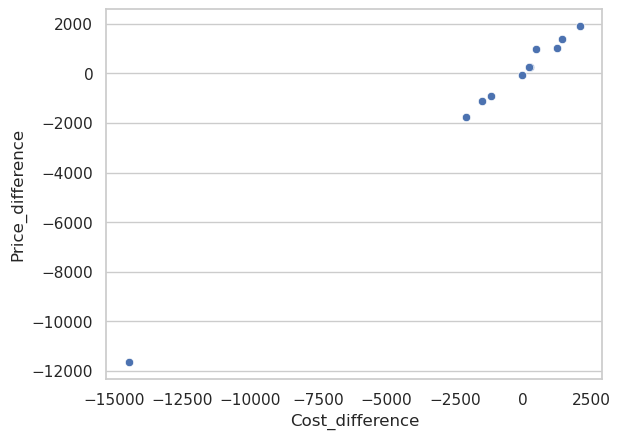

In [265]:
sns.scatterplot(data=final_comp,
                x='Cost_difference',
                y='Price_difference')

In [266]:
final_comp.sort_values(by='Cost_difference')

,Price_difference,Cost_difference,Margin_Difference
Product_ID,,,
P048,-11653.641429,-14450.715714,-12.162467
P074,-1766.373214,-2088.495714,-6.021681
P047,-1121.093571,-1490.260952,-3.275230
P093,-912.645714,-1175.568571,-10.866498
P057,-61.539012,-53.035631,-5.152748
P087,235.926593,211.854286,-5.532316
P051,252.323750,238.790000,-3.885214
P073,986.405500,473.217500,-15.791039
P062,1011.295238,1259.645000,-8.171663


In [267]:
p048_mask=product[product.index.get_level_values(1) == 'P048'][['Profit_Margin','Unit_Price', 'Cost_per_unit']]

In [268]:
p048_mask

,,Profit_Margin,Unit_Price,Cost_per_unit
Store_ID,Product_ID,,,
S001,P048,6.759354,515.814286,480.948571
S007,P048,18.921821,14966.530000,12134.590000


In [269]:
flat_product=product[product.index.get_level_values(0) != 'S001'].reset_index()

In [270]:
flat_product

,Store_ID,Product_ID,Sales,Profit,Quantity,Profit_Margin,Cost,Cost_per_unit,Unit_Price,cost_to_sales
0,S002,P003,6696.98,1719.11,3,25.669929,4977.87,1659.290000,2232.326667,0.743301
1,S002,P009,7589.06,1124.68,5,14.819754,6464.38,1292.876000,1517.812000,0.851802
2,S002,P011,2000.48,550.29,7,27.507898,1450.19,207.170000,285.782857,0.724921
3,S002,P016,15389.47,1417.69,7,9.212078,13971.78,1995.968571,2198.495714,0.907879
4,S002,P024,8305.49,645.60,4,7.773172,7659.89,1914.972500,2076.372500,0.922268
...,...,...,...,...,...,...,...,...,...,...
205,S010,P095,5364.73,699.13,7,13.031970,4665.60,666.514286,766.390000,0.869680
206,S010,P103,13863.86,2208.73,2,15.931566,11655.13,5827.565000,6931.930000,0.840684
207,S010,P104,21072.23,1199.68,6,5.693180,19872.55,3312.091667,3512.038333,0.943068
208,S010,P111,2230.24,479.23,5,21.487822,1751.01,350.202000,446.048000,0.785122


In [271]:
flat_product=flat_product.groupby('Product_ID')['Store_ID'].nunique().reset_index()

In [272]:
problem_products

Index(['P047', 'P048', 'P051', 'P054', 'P057', 'P062', 'P073', 'P074', 'P087',
       'P093', 'P098'],
      dtype='str', name='Product_ID')

In [273]:
flat_product=flat_product[flat_product['Product_ID'].isin(problem_products)]

In [274]:
flat_product.reset_index(drop=True)

,Product_ID,Store_ID
0,P047,2
1,P048,1
2,P051,1
3,P054,4
4,P057,3
5,P062,1
6,P073,1
7,P074,2
8,P087,1
9,P093,1


In [275]:
flat_product=flat_product.set_index('Product_ID')

In [276]:
flat_product

,Store_ID
Product_ID,
P047,2
P048,1
P051,1
P054,4
P057,3
P062,1
P073,1
P074,2
P087,1


In [277]:
final_comp['Comparison_Stores']=flat_product

In [278]:
final_comp.sort_values(by='Comparison_Stores', ascending=False).head()

,Price_difference,Cost_difference,Margin_Difference,Comparison_Stores
Product_ID,,,,
P054,1376.444583,1412.336583,-4.170195,4
P057,-61.539012,-53.035631,-5.152748,3
P047,-1121.093571,-1490.260952,-3.275230,2
P074,-1766.373214,-2088.495714,-6.021681,2
P048,-11653.641429,-14450.715714,-12.162467,1


In [279]:
p047_p074_compare=price_cost_compare.loc[['P047','P074']][['Unit_Price_S001','Cost_per_unit_S001','Profit_Margin_S001','Unit_Price_Other','Cost_per_unit_Other','Profit_Margin_Other']]

In [280]:
p047_p074_compare['Cost_to_Price_S001']=p047_p074_compare['Cost_per_unit_S001']/p047_p074_compare['Unit_Price_S001']

In [281]:
p047_p074_compare['Cost_to_Price_Other']=p047_p074_compare['Cost_per_unit_Other']/p047_p074_compare['Unit_Price_Other']

In [282]:
p047_p074_compare

,Unit_Price_S001,Cost_per_unit_S001,Profit_Margin_S001,Unit_Price_Other,Cost_per_unit_Other,Profit_Margin_Other,Cost_to_Price_S001,Cost_to_Price_Other
Product_ID,,,,,,,,
P047,2380.293333,2018.136667,15.214791,3870.554286,3139.230238,18.490021,0.847852,0.811054
P074,1862.054286,1709.654286,8.184509,3950.550000,3476.027500,14.206190,0.918155,0.879884


In [283]:
p047_p074_compare[['Cost_to_Price_S001','Cost_to_Price_Other']]

,Cost_to_Price_S001,Cost_to_Price_Other
Product_ID,,
P047,0.847852,0.811054
P074,0.918155,0.879884


In [284]:
price_cost_compare['Cost_to_Price_S001']=price_cost_compare['Cost_per_unit_S001']/price_cost_compare['Unit_Price_S001']

In [285]:
price_cost_compare['Cost_to_Price_Other']=price_cost_compare['Cost_per_unit_Other']/price_cost_compare['Unit_Price_Other']

In [286]:
price_cost_compare[['Cost_to_Price_S001','Cost_to_Price_Other']]

,Cost_to_Price_S001,Cost_to_Price_Other
Product_ID,,
P047,0.847852,0.811054
P048,0.932406,0.810782
P051,0.851396,0.812544
P054,0.896876,0.872776
P057,0.909097,0.920179
P062,0.796124,0.714408
P073,0.871887,0.713977
P074,0.918155,0.879884
P087,0.928028,0.872705


In [287]:
mask.xs('P057', level=1)

,Profit_Margin,Unit_Price,Cost_per_unit
Store_ID,,,
S001,9.090344,1149.304286,1044.828571
S003,7.905899,2061.448000,1898.472000
S004,5.539034,1379.933750,1303.498750
S008,29.284343,165.638000,117.132000


In [288]:
final_comp

,Price_difference,Cost_difference,Margin_Difference,Comparison_Stores
Product_ID,,,,
P047,-1121.093571,-1490.260952,-3.275230,2
P048,-11653.641429,-14450.715714,-12.162467,1
P051,252.323750,238.790000,-3.885214,1
P054,1376.444583,1412.336583,-4.170195,4
P057,-61.539012,-53.035631,-5.152748,3
P062,1011.295238,1259.645000,-8.171663,1
P073,986.405500,473.217500,-15.791039,1
P074,-1766.373214,-2088.495714,-6.021681,2
P087,235.926593,211.854286,-5.532316,1


In [289]:
price_cost_compare

,Unit_Price_S001,Cost_per_unit_S001,Profit_Margin_S001,Unit_Price_Other,Cost_per_unit_Other,Profit_Margin_Other,Price_difference,Cost_difference,Cost_to_Price_S001,Cost_to_Price_Other
Product_ID,,,,,,,,,,
P047,2380.293333,2018.136667,15.214791,3870.554286,3139.230238,18.490021,-1121.093571,-1490.260952,0.847852,0.811054
P048,515.814286,480.948571,6.759354,14966.530000,12134.590000,18.921821,-11653.641429,-14450.715714,0.932406,0.810782
P051,1500.470000,1277.493750,14.860427,1261.680000,1025.170000,18.745641,252.323750,238.790000,0.851396,0.812544
P054,5966.586667,5351.286667,10.312429,4554.250083,3974.842083,14.482624,1376.444583,1412.336583,0.896876,0.872776
P057,1149.304286,1044.828571,9.090344,1202.339917,1106.367583,14.243092,-61.539012,-53.035631,0.909097,0.920179
P062,1363.190000,1085.268571,20.387578,103.545000,73.973333,28.559242,1011.295238,1259.645000,0.796124,0.714408
P073,4107.007500,3580.847500,12.811274,3633.790000,2594.442000,28.602313,986.405500,473.217500,0.871887,0.713977
P074,1862.054286,1709.654286,8.184509,3950.550000,3476.027500,14.206190,-1766.373214,-2088.495714,0.918155,0.879884
P087,922.584286,856.184286,7.197174,710.730000,620.257692,12.729490,235.926593,211.854286,0.928028,0.872705


In [290]:
reset_PCC=price_cost_compare.reset_index()

In [291]:
reset_PCC

,Product_ID,Unit_Price_S001,Cost_per_unit_S001,Profit_Margin_S001,Unit_Price_Other,Cost_per_unit_Other,Profit_Margin_Other,Price_difference,Cost_difference,Cost_to_Price_S001,Cost_to_Price_Other
0,P047,2380.293333,2018.136667,15.214791,3870.554286,3139.230238,18.490021,-1121.093571,-1490.260952,0.847852,0.811054
1,P048,515.814286,480.948571,6.759354,14966.530000,12134.590000,18.921821,-11653.641429,-14450.715714,0.932406,0.810782
2,P051,1500.470000,1277.493750,14.860427,1261.680000,1025.170000,18.745641,252.323750,238.790000,0.851396,0.812544
3,P054,5966.586667,5351.286667,10.312429,4554.250083,3974.842083,14.482624,1376.444583,1412.336583,0.896876,0.872776
4,P057,1149.304286,1044.828571,9.090344,1202.339917,1106.367583,14.243092,-61.539012,-53.035631,0.909097,0.920179
5,P062,1363.190000,1085.268571,20.387578,103.545000,73.973333,28.559242,1011.295238,1259.645000,0.796124,0.714408
6,P073,4107.007500,3580.847500,12.811274,3633.790000,2594.442000,28.602313,986.405500,473.217500,0.871887,0.713977
7,P074,1862.054286,1709.654286,8.184509,3950.550000,3476.027500,14.206190,-1766.373214,-2088.495714,0.918155,0.879884
8,P087,922.584286,856.184286,7.197174,710.730000,620.257692,12.729490,235.926593,211.854286,0.928028,0.872705
9,P093,241.632857,219.244286,9.265533,1417.201429,1131.890000,20.132031,-912.645714,-1175.568571,0.907345,0.798680


In [292]:
melted_margin=reset_PCC.melt(
    id_vars='Product_ID',
    value_vars=['Profit_Margin_S001','Profit_Margin_Other'],
    var_name='Store_group',
    value_name='Profit_Margin'
)

In [293]:
melted_margin

,Product_ID,Store_group,Profit_Margin
0,P047,Profit_Margin_S001,15.214791
1,P048,Profit_Margin_S001,6.759354
2,P051,Profit_Margin_S001,14.860427
3,P054,Profit_Margin_S001,10.312429
4,P057,Profit_Margin_S001,9.090344
5,P062,Profit_Margin_S001,20.387578
6,P073,Profit_Margin_S001,12.811274
7,P074,Profit_Margin_S001,8.184509
8,P087,Profit_Margin_S001,7.197174
9,P093,Profit_Margin_S001,9.265533


Text(52.90508789062501, 0.5, 'Profit Margin (%)')

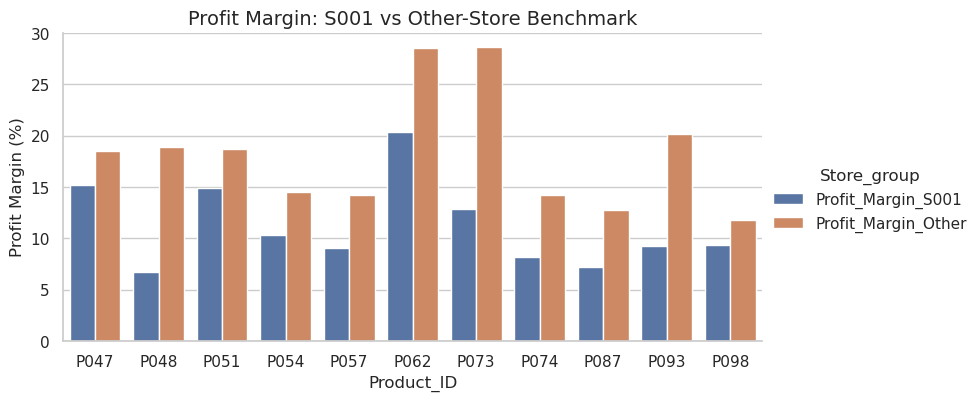

In [294]:
sns.catplot(data=melted_margin,
            x='Product_ID',
            y='Profit_Margin',
            hue='Store_group',
            kind='bar',
           height=4,
           aspect=2)
plt.title('Profit Margin: S001 vs Other-Store Benchmark', fontsize=14)
plt.ylabel('Profit Margin (%)')


In [295]:
final_df=final_comp.sort_values(by='Margin_Difference')

Text(0, 0.5, 'Product ID')

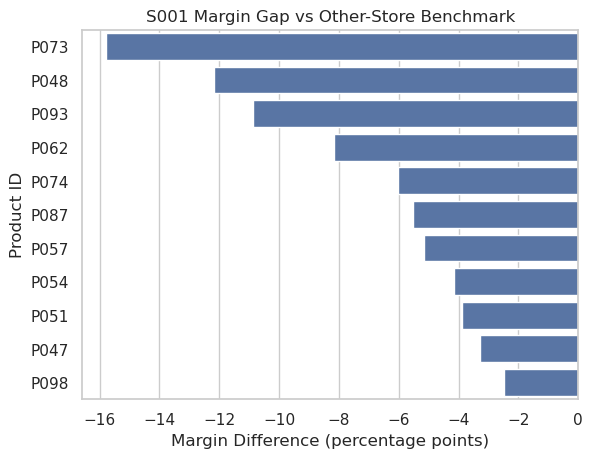

In [296]:
sns.barplot(data=final_df,
             x='Margin_Difference',
             y='Product_ID')
plt.grid(axis='x') 
plt.title('S001 Margin Gap vs Other-Store Benchmark')
plt.xlabel('Margin Difference (percentage points)')
plt.ylabel('Product ID')

In [297]:
reset_FC=final_comp.reset_index()

In [298]:
final_df

,Price_difference,Cost_difference,Margin_Difference,Comparison_Stores
Product_ID,,,,
P073,986.405500,473.217500,-15.791039,1
P048,-11653.641429,-14450.715714,-12.162467,1
P093,-912.645714,-1175.568571,-10.866498,1
P062,1011.295238,1259.645000,-8.171663,1
P074,-1766.373214,-2088.495714,-6.021681,2
P087,235.926593,211.854286,-5.532316,1
P057,-61.539012,-53.035631,-5.152748,3
P054,1376.444583,1412.336583,-4.170195,4
P051,252.323750,238.790000,-3.885214,1


In [299]:
melted_cost_to_price=reset_PCC.melt(
                        id_vars='Product_ID',
                        value_vars=['Cost_to_Price_S001','Cost_to_Price_Other'],
                        var_name='Store_group',
                        value_name='Cost_to_Price')

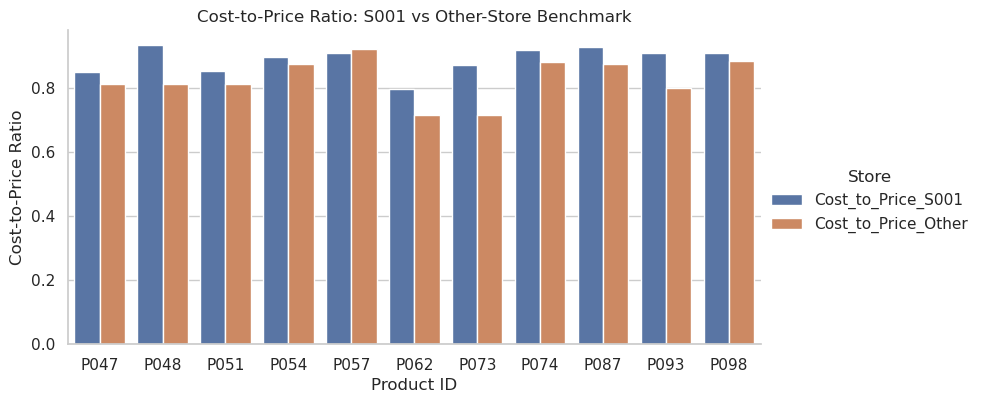

In [300]:
ax=sns.catplot(data=melted_cost_to_price,
            x='Product_ID',
            y='Cost_to_Price',
            hue='Store_group',
           kind='bar',
           height=4,
           aspect=2)
ax.set(
    title='Cost-to-Price Ratio: S001 vs Other-Store Benchmark',
    xlabel='Product ID',
    ylabel='Cost-to-Price Ratio')

ax.legend.set_title('Store')

plt.show()

## 4.12 Business Conclusion

The analysis identified Bengaluru Grocery as a relatively lower-margin city-category combination. The investigation did not find strong evidence that discounts, returns, payment mode, or quantity were the primary drivers of the lower margin.

The deeper store-level investigation highlighted S001 as a relatively weaker-performing store. Product-level benchmarking showed that several products had materially lower profit margins in S001 compared with the average of other stores.

Further analysis of price and cost differences suggested that the margin gap was associated with differences in the underlying price-cost structure for these products. The relationship should be interpreted as an association rather than a causal effect, particularly given the small number of underperforming products used in the final comparison.

Overall, the analysis suggests that **product-level price and cost management at S001 is a more relevant area for investigation than broad discounting, returns, payment mode, or quantity behavior.**